# Riconoscimento di animali dalle tracce audio (.wav)
*Flavio Simonelli 0365333*

## 1. Traccia T4 (Riconoscimento di animali da tracce audio)
Si consideri un dataset contenente registrazioni audio.
Si richiede di classificare le tracce riconoscendo la specie animale che l'ha prodotta.
Il dataset fornito (cats dogs dolphins.zip) contiene suoni etichettati di 3 specie animali (i.e., cani, gatti e delfini).
Si richiede di sviluppare e confrontare 2 diversi modelli:
- un modello che prenda in input direttamente la forma d'onda associata a ciascuna traccia (i.e., sequenze)
- un modello che prenda in input lo spettrogramma di ciascuna traccia, ovvero la rappresentazione grafica dell'intensità di un suono in funzione del tempo e della frequenza.

## 2.  Analisi Teorica del Problema <a id="analisi-teorica"></a>


Il problema della classificazione dei versi degli animali può essere considerato un'estensione del riconoscimento del parlato umano, adattata all'analisi di segnali audio non verbali.  

Le principali caratteristiche acustiche che distinguono i versi degli animali includono:  

- **Frequenza dominante e spettro di frequenza**: identificano univocamente la firma acustica di ciascun animale;  
- **Cadenza e periodicità del segnale audio**: contribuisce alla discriminazione tramite i diversi pattern vocali.  

In questo capitolo si fa riferimento a diversi studi che analizzano le principali tipologie di vocalizzazioni per ciascuna delle tre specie considerate. Oltre a caratteristiche generali (come il significato semantico del verso, l'energia RMS e i coefficienti MFCC) nei seguenti riferimenti vengono analizzate le fue caratteristiche fondamentali prima elencate.
In questo capitolo ne viene riportato un breve riassunto.


### 2.1. Vocalizzazioni dei Delfini

I delfini emettono principalmente tre tipi di suoni:

- **Fischi (Whistles)**: spesso utilizzati per la comunicazione.
- **Clic (Clicks)**: impiegati per l'ecolocalizzazione.
- **BPS (Burst Pulse Sounds)**: sequenze rapide di click che sembrano avere anche una funzione comunicativa.

#### Caratteristiche principali

| Caratteristica            | Fischi (Whistles)                     | Clic (Clicks)                          | BPS (Burst Pulse Sounds)               |
|---------------------------|--------------------------------------|---------------------------------------|----------------------------------------|
| **Tipo di suono**         | Tonale e modulato                    | Impulsivo e ad alta frequenza         | Sequenza rapida di impulsi            |
| **Frequenza fondamentale**| 2 kHz - 24 kHz                        | 0,2 kHz - 150 kHz                      | 0,2 kHz - 16 kHz                      |
| **Durata** |0,05 s - 2 s | impulsivi | media 0,1 s
| **Spettrogramma**         | Linee curve o ondulate               | Impulsi verticali                     | Sequenze di impulsi ravvicinati       |

> Fonte: [Università di Bari](https://vetjournal.it/images/archive/pdf_riviste/4046.pdf)

### 2.2. Vocalizzazioni dei Gatti

I gatti emettono principalmente tre tipi di suoni:

- **Miagolii**: spesso utilizzati per la comunicazione.
- **Fusa**: suoni continui e ritmici emessi quando il gatto è rilassato o in cerca di conforto.
- **Sibili**: suoni acuti e prolungati emessi in situazioni di difesa o minaccia.

#### Caratteristiche principali

| Caratteristica            | Miagolii                              | Fusa                                  | Sibili                                 |
|---------------------------|--------------------------------------|--------------------------------------|---------------------------------------|
| **Tipo di suono**         | Tonale                   | Ritmico                  | Acuto e prolungato                    |
| **Frequenza fondamentale**| 300 Hz - 6 kHz                       | 20 Hz - 150 Hz                       | 3 kHz - 8 kHz                         |
| **Durata**      | Variabile, da breve a prolungata     | Lunga e costante                      | Breve o prolungata                     |
| **Spettrogramma**         | Linee curve o irregolari             | Banda costante                        | Linee acute e nette                   |

>Fonte: [Wikipedia](https://en.wikipedia.org/wiki/Purr#cite_note-:0-4)

### 2.3. Vocalizzazioni dei cani

I cani emettono principalmente tre tipi di suoni:

- **Abbai**: utilizzati per la comunicazione.
- **Guaiti**: suoni acuti ed espressivi.
- **Ringhi**: suoni gutturali e continui, spesso utilizzati per avvertire o mostrare aggressività.

####  Caratteristiche principali

| Caratteristica            | Abbai                                 | Guaiti                                | Ringhi                                 |
|---------------------------|--------------------------------------|--------------------------------------|---------------------------------------|
| **Tipo di suono**         | Breve e ripetitivo                   | Acuto e lamentoso                     | Gutturale e continuo                   |
| **Frequenza fondamentale**| 400 Hz - 7 kHz                        | 600 Hz - 8 kHz                        | 100 Hz - 1 kHz                         |
| **Durata del suono**      | Breve, generalmente < 1 s            | Variabile, da breve a prolungata      | Lunga e costante                      |
| **Spettrogramma**         | Impulsi ripetuti e ben separati      | Linee acute e irregolari              | Banda continua e densa                |

## 3. Analisi operativa del dataset

Dopo aver inquadrato il problema attraverso un'analisi teorica e individuato le informazioni chiave su cui il nostro modello può basarsi per la classificazione, possiamo procedere con un'analisi operativa del dataset fornito.  

In questo capitolo esaminiamo i campioni audio presenti nel dataset, focalizzandoci sulle principali caratteristiche distintive, quali:  

- **Durata dei campioni**: parametro utile per comprendere la variabilità temporale dei versi;  
- **Frequenza di campionamento**: elemento determinante per la qualità e la risoluzione dell'analisi spettrale.  

Questa fase di esplorazione preliminare è essenziale per comprendere la struttura del dataset e individuare eventuali pre-elaborazioni necessarie prima della fase di modellazione.  



### 3.1. Librerie utilizzate

In questo capitolo vengono utilizzate diverse librerie per la gestione, l'analisi e la visualizzazione dei dati. Di seguito, un elenco delle principali librerie impiegate e il loro utilizzo:  

- **os**: consente di navigare tra le cartelle del dataset e gestire i file in modo programmatico.  
- **librosa**: utilizzato per il caricamento dei campioni audio senza perdita di informazioni sul sample rate e per la visualizzazione di forme d'onda e spettrogrammi direttamente nel notebook.  
- **defaultdict**: una variante dei dizionari Python che semplifica la lettura del codice, creando automaticamente una nuova chiave se questa non esiste.  
- **pandas**: utilizzato per la creazione e gestione di DataFrame, facilitando l'analisi strutturata delle informazioni sui campioni audio.  
- **matplotlib** e **seaborn**: impiegati per la generazione di grafici e la visualizzazione delle distribuzioni dei dati.  
- **numpy**: utilizzato per la manipolazione e l'elaborazione dei campioni audio.  
- **soundfile**: necessario per la codifica e la gestione di file audio in formato WAV.
- **IPython.display**: per ascoltare un audio direttamente dal notebook

Queste librerie consentono un'analisi approfondita e una gestione efficace del dataset, facilitando la fase di pre-elaborazione e visualizzazione dei dati.  



In [ ]:
import os
import librosa
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import soundfile as sf
import IPython.display as ipd

### 3.2. Caricamento del Dataset

La prima operazione da effettuare nel caso in cui il dataset è all'interno di google drive è eseguire il seguente codice.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Identifichiamo il percorso della directory di training.

In [ ]:
# path della directory di training
ORIGINAL_TRAIN_PATH = "/content/drive/MyDrive/Dataset/cats_dogs_dolphins/train"

# Controllo sull'esistenza della directory
if not os.path.exists(ORIGINAL_TRAIN_PATH):
    print(f"Attenzione: la directory {ORIGINAL_TRAIN_PATH} non esiste!")

Per gestire il dataset audio, definiamo una funzione che ne effettua il caricamento in un dizionario a partire dalla directory principale.  

A differenza di `tf.keras.utils.audio_dataset_from_directory`, questa implementazione permette di accedere a informazioni fondamentali sui campioni, come il **sample rate**, essenziale per un'analisi approfondita dei segnali audio.  

L'organizzazione dei dati in un **dizionario** facilita il successivo pre-processing e l'estrazione delle feature, garantendo maggiore flessibilità nella gestione del dataset.

Anche in questa funzione si assume che il dataset sia organizzato nella seguente struttura:

```
main_directory/
...class_a/
......a_audio_1.wav
......a_audio_2.wav
...class_b/
......b_audio_1.wav
......b_audio_2.wav
```

In [ ]:
# Carica i file audio da una directory strutturata in classi e li memorizza in un dizionario.
def load_from_directory(dir, dictionary):
  for label in os.listdir(dir): # itera su ogni sottocartella
    label_path = os.path.join(dir, label)
    if os.path.isdir(label_path):
        for file in os.listdir(label_path): # Itera su ogni file nella sottocartella
            if file.lower().endswith('.wav'):  # Filtra per file audio (estensione .wav)
                file_path = os.path.join(label_path, file)
                audio, sr = librosa.load(file_path, sr=None) # Carica il file mantenendo il sample rate originale
                dictionary[label].append((audio, sr)) # Aggiungi una tupla nel dizionario seguendo la chiave label: (audio, sr)

Utilizziamo `load_from_directory` per caricare il dataset di training nel dizionario `train_dict`.

Viene utilizzato un `defaultdict` solo per facilitare la lettura del codice (non richiede la creazione delle chiavi prima di inserire gli elementi nel dizionario)

In [ ]:
train_dict = defaultdict(list) # dizionario dataset originale di training

load_from_directory(ORIGINAL_TRAIN_PATH, train_dict)

Per analizzare i campioni caricati stampiamo delle informazioni di debug

Numero di classi nel dataset di training: 3
Classi nel dataset di training: cat, dolphin, dog
Tipi di dati caricati tramite librosa:
Tipo di train_dict['dog'][0]: <class 'tuple'>
Tipo di train_dict['dog'][0][0]: <class 'numpy.ndarray'>
Tipo di train_dict['dog'][0][1]: <class 'int'>


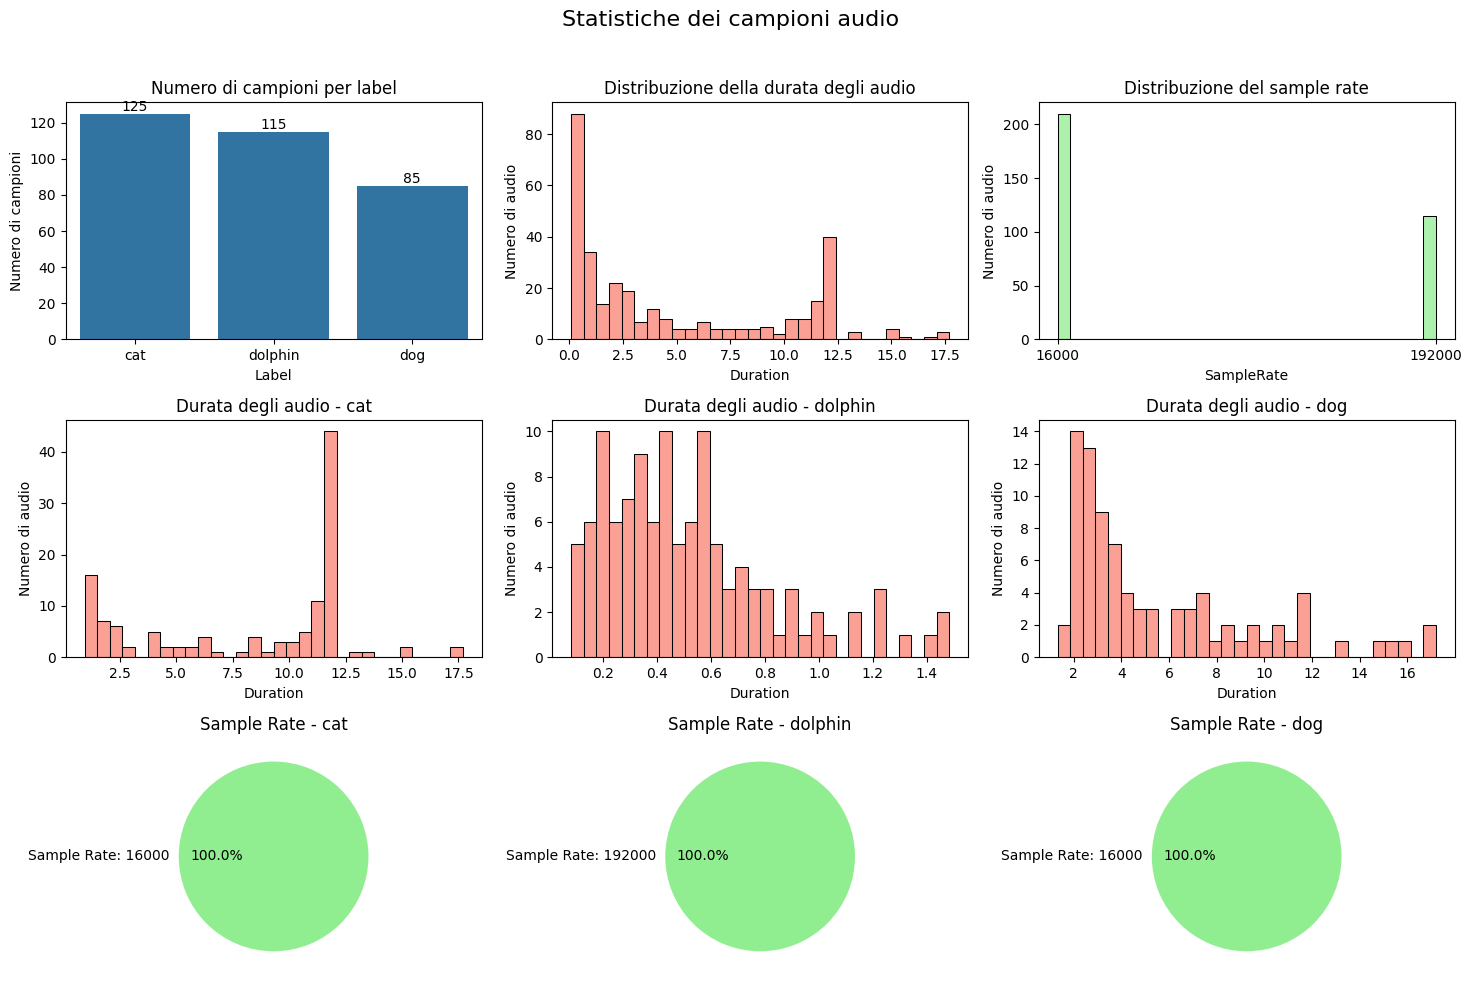

In [ ]:
# Analisi info di debug sul dataset di training
print("Numero di classi nel dataset di training:", len(train_dict))
print("Classi nel dataset di training:", ", ".join(train_dict.keys()))
print("Tipi di dati caricati tramite librosa:")
print(f"Tipo di dato della tupla (audio, sample rate): {type(train_dict['dog'][0])}")
print(f"Tipo di dato dell'audio: {type(train_dict['dog'][0][0])}")
print(f"Tipo di dato del sample rate: {type(train_dict['dog'][0][1])}")

# Creazione del DataFrame per i dati di debug
data = []
for label, samples in train_dict.items():
    for audio, sr in samples:
        duration = len(audio) / sr
        data.append([label, duration, sr])

df = pd.DataFrame(data, columns=["Label", "Duration", "SampleRate"])

# Creazione del subplot 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Statistiche dei campioni audio', fontsize=16)

# 1. Numero di campioni per label
sns.countplot(data=df, x="Label", ax=axes[0, 0])
axes[0, 0].set_title('Numero di campioni per label')
axes[0, 0].set_ylabel('Numero di campioni')
axes[0, 0].tick_params(axis='x')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, color='black')

# 2. Distribuzione della durata degli audio
sns.histplot(df["Duration"], bins=30, ax=axes[0, 1], color="salmon")
axes[0, 1].set_title('Distribuzione della durata degli audio')
axes[0, 1].set_ylabel('Numero di audio')

# 3. Distribuzione del sample rate
sns.histplot(df["SampleRate"], bins=30, ax=axes[0, 2], color="lightgreen")
axes[0, 2].set_title('Distribuzione del sample rate')
axes[0, 2].set_ylabel('Numero di audio')
axes[0, 2].set_xticks(sorted(df["SampleRate"].unique()))

# Seconda riga: Distribuzione della durata per ogni label
labels = df["Label"].unique()
num_labels = len(labels)

for i, label in enumerate(labels):
    row = 1  # Riga dei grafici della durata
    col = i
    sns.histplot(df[df["Label"] == label]["Duration"], bins=30, ax=axes[row, col], color="salmon")
    axes[row, col].set_title(f'Durata degli audio - {label}')
    axes[row, col].set_ylabel('Numero di audio')

# Terza riga: Distribuzione del sample rate per ogni label
for i, label in enumerate(labels):
    row = 2  # Riga dei grafici del sample rate
    col = i
    sample_rate_values = df[df["Label"] == label]["SampleRate"].unique()

    # Se c'è un solo valore di sample rate, usiamo un grafico a torta
    if len(sample_rate_values) == 1:
        axes[row, col].pie([1], labels=[f'Sample Rate: {sample_rate_values[0]}'], autopct='%1.1f%%', colors=["lightgreen"])
        axes[row, col].set_title(f'Sample Rate - {label}')
    else:
        # Se ci sono più valori, usiamo un istogramma
        sns.histplot(df[df["Label"] == label]["SampleRate"], bins=30, ax=axes[row, col], color="lightgreen")
        axes[row, col].set_title(f'Sample Rate - {label}')
        axes[row, col].set_ylabel('Numero di audio')

# Ottimizzazione del layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 3.3. Analisi dei grafici e considerazioni sui dati

Dall'osservazione dei grafici emerge quanto segue:

- **Numero di campioni disponibili**  
  Il dataset è composto da **325 campioni totali**, un numero probabilmente insufficiente per l'addestramento di reti neurali troppo complesse.

- **Lunghezza variabile dei campioni e implicazioni computazionali**  
  La lunghezza dei campioni varia, con il più lungo pari a **17,5 secondi**. Considerando una frequenza di campionamento di **16 kHz**, questo corrisponde a:  

  $$
  16000\ Hz \times 17,5\ s = 280000\ campioni
  $$

  Tale dimensione dell'input risulta proibitiva in termini di gestione computazionale.
  A questo scopo risulta indispensabile un **Troncamento** dei campioni.

- **Frequenza di campionamento**  
  I campioni audio sono distribuiti su due diverse frequenze di campionamento:  
  - Gli audio di **cani e gatti** sono stati campionati a **16 kHz**.  
  - Gli audio di **delfini** sono stati campionati a **192 kHz**.  

  Questo risultato è coerente con l'analisi teorica svolta in precedenza, poiché i versi dei delfini vengono emessi a frequenze significativamente più elevate rispetto a quelle di cani e gatti. In particolare, secondo il **Teorema di Nyquist**:  

  > Un segnale periodico deve essere campionato a più del doppio della componente di frequenza più alta del segnale.  

  Ne consegue che, se la frequenza di campionamento fosse troppo bassa, i versi dei delfini potrebbero non essere adeguatamente catturati.  

  Tuttavia, non è possibile utilizzare per l'addestramento due frequenze di campionamento differenti, specialmente in un caso come il nostro, in cui tutti gli audio di ciascuna classe condividono una specifica frequenza di campionamento. Durante la fase di inferenza, non avendo il valore target, sarà necessario effettuare il **resampling** a una frequenza di campionamento uniforme.  

  La **frequenza di campionamento** è definita come:  

  > Il numero di campioni presenti in un secondo di segnale digitale, espresso in Hertz.  

  Utilizzare frequenze di campionamento differenti porterebbe alla perdita di una delle feature fondamentali individuate nell'analisi teorica, ovvero la **dipendenza temporale e la cadenza dei versi**. Infatti, un audio con una frequenza di campionamento più alta rispetto ai dati di training sarebbe interpretato dal modello come rallentato, mentre uno con una frequenza inferiore risulterebbe velocizzato.


Definiamo delle funzioni per stampare nel notebook le forme d'onda, gli spettrogrammi e ascoltare un audio.

In [ ]:
# Riproduce audio direttamente ne Notebook
def play_audio(audio, sr):
    ipd.display(ipd.Audio(audio, rate=sr))

# Mostra la forma d'onda
def plot_waveform(audio, sr, fig, ax, title='Forma d\'onda'):
    librosa.display.waveshow(audio, sr=sr, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Ampiezza')

# Mostra lo spettrogramma STFT
def plot_spectrogram_STFT(audio, sr, fig, ax, y_scale='log',title='Spettrogramma (STFT)'):
    D = librosa.stft(audio)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis=y_scale, ax=ax)

    ax.set_title(title)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_ylabel('Frequenza (Hz)')
    ax.set_xlabel('Tempo (s)')

# Mostra lo spettrogramma Mel
def plot_spectrogram_Mel(audio, sr, fig, ax, nmels=128, title='Spettrogramma (Mel)'):
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=nmels)
    S_db_mel = librosa.amplitude_to_db(S, ref=np.max)

    img = librosa.display.specshow(S_db_mel, sr=sr, x_axis='time', y_axis='mel', ax=ax)

    ax.set_title(title)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_ylabel('Frequenza (Hz)')
    ax.set_xlabel('Tempo (s)')

Stampiamo per dimostrazioni un esempio di forma d'onda, spettrogramma e relativo audio per ogni classe.

 Esempio di audio - Delfino:


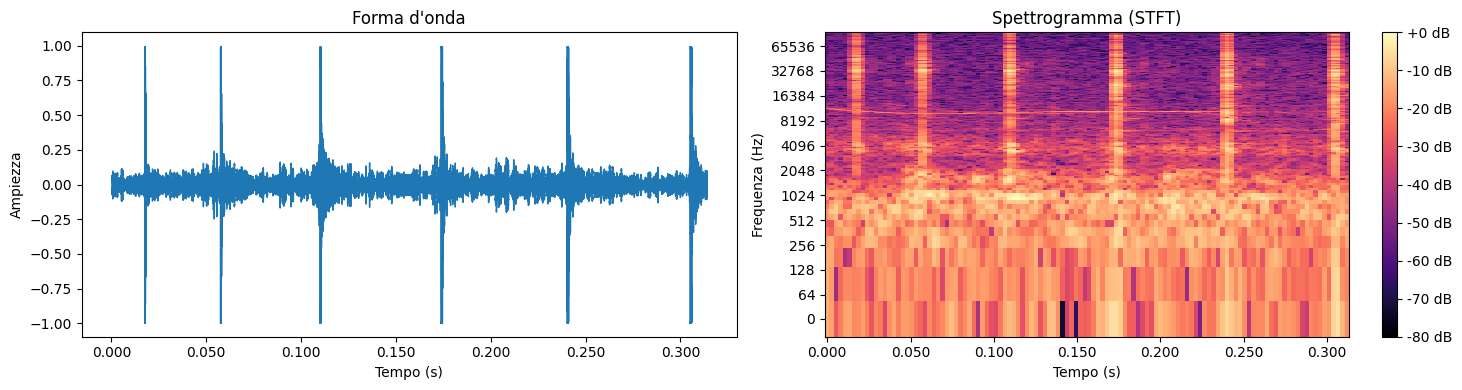

 Esempio di audio - Gatto:


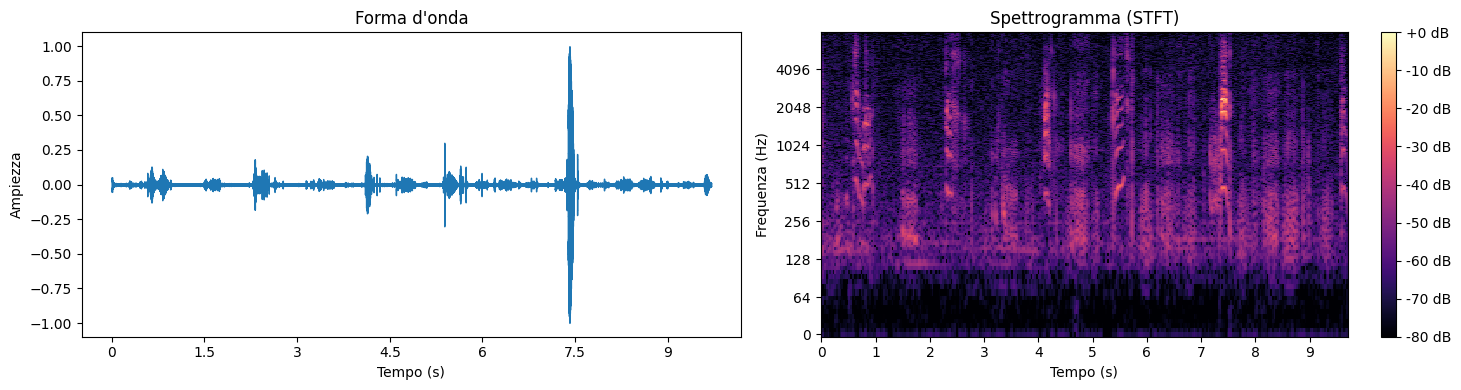

 Esempio di audio - Cane:


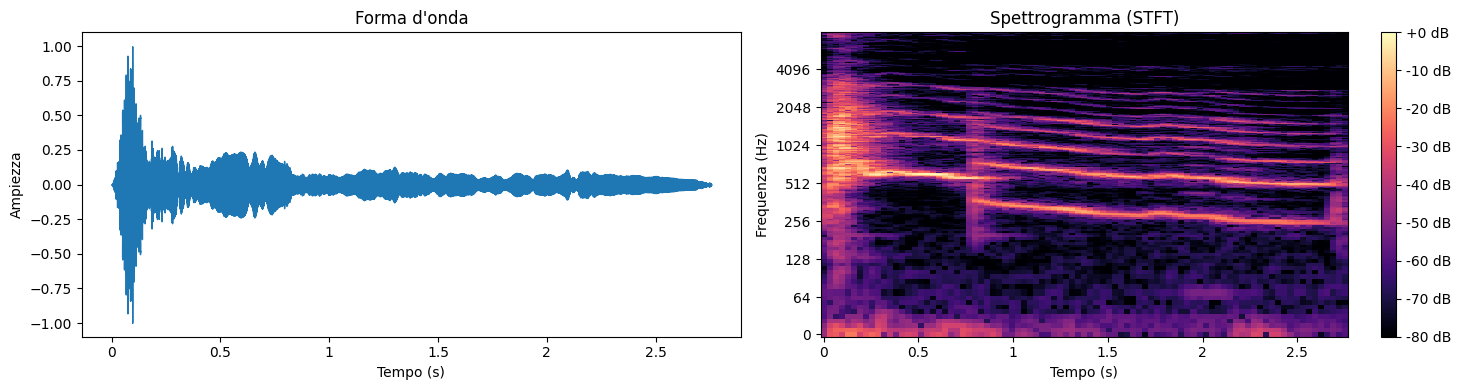

In [ ]:
print("\033[1;34m Esempio di audio - Delfino:\033[0m")
play_audio(train_dict['dolphin'][0][0], train_dict['dolphin'][0][1])
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
plot_waveform(train_dict['dolphin'][0][0], train_dict['dolphin'][0][1], fig, ax1)
plot_spectrogram_STFT(train_dict['dolphin'][0][0], train_dict['dolphin'][0][1], fig, ax2)
plt.tight_layout()
plt.show()

print("\033[1;34m Esempio di audio - Gatto:\033[0m")
play_audio(train_dict['cat'][0][0], train_dict['cat'][0][1])
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
plot_waveform(train_dict['cat'][0][0], train_dict['cat'][0][1], fig, ax1)
plot_spectrogram_STFT(train_dict['cat'][0][0], train_dict['cat'][0][1], fig, ax2)
plt.tight_layout()
plt.show()

print("\033[1;34m Esempio di audio - Cane:\033[0m")
play_audio(train_dict['dog'][0][0], train_dict['dog'][0][1])
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
plot_waveform(train_dict['dog'][0][0], train_dict['dog'][0][1], fig, ax1)
plot_spectrogram_STFT(train_dict['dog'][0][0], train_dict['dog'][0][1], fig, ax2)
plt.tight_layout()
plt.show()


### 3.4 Data augmentation

Per incrementare il numero di campioni di training, possiamo applicare diverse tecniche di **data augmentation**, suddivise in base al tipo di trasformazione.

**1. Trasformazioni temporali**
- **Time Stretching** ❌  
  Alterare la velocità di emissione del verso potrebbe generare dati irrealistici, poiché la velocità è una caratteristica distintiva di ogni specie.  
- **Pitch Shifting** ❌  
  Modificare la tonalità di un verso non è appropriato, in quanto la frequenza è una feature fondamentale e un'alterazione porterebbe alla perdita di informazioni importanti, influenzando anche i processi di riduzione del rumore.  
- **Time Shifting** ✅  
  Spostare temporalmente il segnale senza modificarne il contenuto potrebbe essere utile, in quanto non altera la natura del verso ma rende il modello più robusto rispetto alla posizione dell'audio nel tempo.  
- **Time Masking** ✅  
  Simile al **dropout** sui dati di training, questa tecnica oscura parti dell'audio, favorendo una maggiore generalizzazione del modello.  

**2. Trasformazioni basate sulla frequenza**
- **Spec Augment** ✅  
  Analogo al **Time Masking**, ma operante sul dominio della frequenza. Oscurare selettivamente parti dello spettrogramma aiuta a rendere il modello più robusto a variazioni nelle frequenze emesse dagli animali.  

**3. Trasformazioni basate sul rumore**
- **Aggiunta di rumore ambientale** ✅  
  Integrare rumori di fondo realistici o riverberi migliora la capacità del modello di generalizzare a contesti reali.  
- **Volume Scaling** ✅  
  Modificare l'intensità dell'audio consente di variare la dinamica del segnale, simulando registrazioni effettuate con diverse condizioni di acquisizione.  

**4. Segmentazione e permutazione dei versi**

Durante lo sviluppo del progetto, è emersa un'idea innovativa per aumentare la variabilità dei dati: **segmentare i versi degli animali all'interno di ciascuna traccia audio ed effettuare una permutazione di questi segmenti**.
L'idea e il risultato sono particolarmente promettenti poichè permette di sintetizzare un numero fattoriale di nuovi audio che cercano di imitare il continuo delle registrazioni originali. Il problema nasce dalle risorse computazionali utilizzate per lo sviluppo del progetto. Anche con l'utilizzo della più performante GPU offerta da Google Colab *NVIDIA L4* il training di sequenze così lunghe di dati richiede una grande quantità di tempo.
Per questo motivo, la sperimentazione di questa tecnica è stata spostata alla parte finale del notebook, come possibile strategia alternativa per future ottimizzazioni del dataset o come idea per prolemi più complessi.

#### **5. Segmentazione del dataset**

Data la dimensione ridotta del training set, è stato possibile analizzare manualmente tutti i campioni con una lunghezza superiore a **3 secondi**. Questa analisi empirica ha confermato che segmentando gli audio più lunghi in porzioni di **3 secondi**, ogni segmento conterrà **almeno un verso dell'animale**.

 **(questa operazione è attuabile solo ed esclusivamente perchè i dati di training sono stati analizzati singolarmente per confermare la precedente affermazione)**

Una dimostrazione di questa osservazione è disponibile nel capitolo finale **[Segmentazione e Permutazione dei Versi](#segmentazione-e-permutazione)**, dove viene illustrato il campionamento dei silenzi tra le vocalizzazioni all'interno dello stesso audio.

Possiamo sfruttare questa proprietà per aumentare la dimensione del nostro dataset, senza introdurre alterazioni artificiali nei dati.  

Si è scelto di segmentare gli audio in blocchi di **3 secondi**, anche se le pause tra le vocalizzazioni sono generalmente più brevi, per i seguenti motivi:
- **Preservare la cadenza delle vocalizzazioni**, una delle caratteristiche chiave identificate nell'**[Analisi Teorica](#analisi-teorica)**.
- **Garantire una lunghezza uniforme degli input**, semplificando il processamento e il training del modello.
- **Evitare il troncamento di informazioni rilevanti**, assicurando che ogni segmento mantenga la struttura originale del verso.
- **Compromesso ottimale** per l'efficienza computazionale.

Questa scelta consente di **migliorare la qualità dei dati di training**, offrendo al modello una rappresentazione più realistica della variabilità nei versi degli animali.


Definiamo una funzione che suddivide gli audio con durata superiore a 3 secondi in segmenti da 3 secondi ciascuno.  

Ogni audio viene diviso in blocchi di 3 secondi. Se la lunghezza dell'audio non è un multiplo di 3 secondi, la parte rimanente viene gestita in base alla sua durata:  
- Se il segmento residuo è più corto del valore impostato in `min_duration`, viene scartato per evitare di introdurre campioni contenenti solo rumore.  
- Se supera `min_duration`, viene mantenuto come ulteriore campione.  

Questa strategia aiuta a evitare campioni troppo brevi e garantisce coerenza negli input del modello, preservando al contempo la cadenza delle vocalizzazioni analizzata in precedenza. La funzione verrà applicata a tutti gli audio del dataset per uniformarne la durata prima della fase di training.


In [ ]:
# Funzione che divide gli audio in segmenti da una lunghezza prefissata e restituisce una lista di segmenti
def split_audio_to_segments(audio_tuple, segment_duration=3, min_duration=2):
    audio_data, sample_rate = audio_tuple # Estrai l'array audio e il sample rate dalla tupla
    samples_per_segment = segment_duration * sample_rate # Calcola il numero di campioni per ogni segmento
    segments = []  # Lista per i segmenti
    # Se l'audio è più corto della durata richiesta, restituiscilo così com'è
    if len(audio_data) < samples_per_segment:
        segments.append((audio_data, sample_rate))
        return segments
    # Se l'audio è più lungo, suddividilo in segmenti completi
    for start in range(0, len(audio_data), samples_per_segment):
        end = start + samples_per_segment
        segment = audio_data[start:end]
        # Aggiungi il segmento solo se è lungo almeno `min_duration`
        if len(segment) >= min_duration*sample_rate:
            segments.append((segment, sample_rate))

    return segments

Allochiamo un nuovo dizionario che conterra tutti gli audio originali segmentati.

In [ ]:
# Dizionario degli audio segmentati
segmented_train_dict = defaultdict(list)

# Segmentiamo gli audio originali in parti da 3 secondi e le inseriamo nel nuovo dizionario
for label, samples in train_dict.items():
  for sample in samples:
    segments = split_audio_to_segments(sample, 3, 2)
    segmented_train_dict[label].extend(segments)

#Stampiamo informazioni di debug per sapere il nuovo numero di campioni di trianing
print("Numero di campioni per classe nel dataset di training segmentato:")
print(f"- Classe 'dog': {len(segmented_train_dict['dog'])} campioni")
print(f"- Classe 'cat': {len(segmented_train_dict['cat'])} campioni")
print(f"- Classe 'dolphin': {len(segmented_train_dict['dolphin'])} campioni")

Numero di campioni per classe nel dataset di training segmentato:
- Classe 'dog': 155 campioni
- Classe 'cat': 355 campioni
- Classe 'dolphin': 115 campioni


Come era prevedibile dall'analisi precedente del training set, il numero dei campioni della classe **gatti** si è notevolmente aumentato, essendo quella con gli audio più lunghi. Il numero degli audio dei **cani** è anch'esso cresciuto, mentre quello dei **delfini** è rimasto invariato, dato che tutti i loro audio erano inferiori ai 3 secondi.

Per evitare di avere un dataset sbilanciato, dobbiamo applicare alcune delle tecniche di **dataset augmentation** precedentemente descritte, in particolare per le classi dei cani e dei delfini. Una delle tecniche che utilizzeremo è il **volume scaling**, che permette di rendere i modelli più robusti ai cambiamenti nel volume dell'audio. Questa è una tecnica appropriata, poiché la variazione di volume dipende dal **microfono** usato per la registrazione, e non è una caratteristica intrinseca della vocalizzazione degli animali.

Inoltre, per evitare che lo scaling produca valori fuori dall'intervallo normale di **[-1, 1]** (valore tipico per i dati audio normalizzati), utilizziamo la funzione `np.clip` di numpy. Questa funzione modifica le forme d'onda **appiattendo i picchi** che escono dall'intervallo, garantendo che i valori rientrino nella gamma accettabile senza distorcere eccessivamente il segnale. Questo può essere visto per i modelli che si baseranno sulle forme d'onda grezze come un rumore aggiuntivo visto che si perde una parte della curva nei picchi di intensità.


In [ ]:
# Volume scaling

# Numero di audio sintetici per ogni audio
NUM_AUG_VOLUME_DOG = 1
NUM_AUG_VOLUME_CAT = 0
NUM_AUG_VOLUME_DOLPHIN = 2

# Funzione che effettua il volume scaling su un segnale audio
def volume_scaling(audio_tuple, scaling_range=(0.5, 1.5)):
    audio_data, sample_rate = audio_tuple
    # Genera un fattore casuale tra scaling_range[0] e scaling_range[1]
    scale_factor = np.random.uniform(scaling_range[0], scaling_range[1])
    # Applica il volume scaling
    scaled_audio = audio_data * scale_factor
    # Clipping per evitare valori fuori dall'intervallo [-1, 1] (se normalizzato)
    scaled_audio = np.clip(scaled_audio, -1.0, 1.0)

    return scaled_audio


In [ ]:
# Applichiamo volume scaling si segmenti campione
augmented_train_dict = defaultdict(list)

for label, samples in segmented_train_dict.items():
    if label == 'dog':
      for sample in samples:
        for _ in range(NUM_AUG_VOLUME_DOG):
          augmented_train_dict[label].append((volume_scaling(sample),sample[1]))
    if label == 'cat':
      for sample in samples:
        for _ in range(NUM_AUG_VOLUME_CAT):
          augmented_train_dict[label].append((volume_scaling(sample),sample[1]))
    if label == 'dolphin':
      for sample in samples:
        for _ in range(NUM_AUG_VOLUME_DOLPHIN):
          augmented_train_dict[label].append((volume_scaling(sample),sample[1]))

In [ ]:
print(len(augmented_train_dict['dog']))
print(len(augmented_train_dict['cat']))
print(len(augmented_train_dict['dolphin']))

155
0
230


In [ ]:
print("totale audio di training per gatti:", len(augmented_train_dict['cat'])+len(segmented_train_dict['cat']))
print("totale audio di training per cani:", len(augmented_train_dict['dog'])+len(segmented_train_dict['dog']))
print("totale audio di training per dolini:", len(augmented_train_dict['dolphin'])+len(segmented_train_dict['dolphin']))

totale audio di training per gatti: 355
totale audio di training per cani: 310
totale audio di training per dolini: 345


Il numero di campioni totali di training dopo la data augmentation è diventato $1010$

### 3.5 Resampling

Per quanto riguarda la frequenza di campionamento, come detto precedentemente, è necessario scegliere una frequenza uniforme per tutti gli audio. L'obiettivo è trovare un trade-off tra la perdita di informazioni dovuta al downscaling e la grandezza delle sequenze di input derivanti dalla frequenza di campionamento.

La scelta è stata fatta a **16 kHz** , poiché questa è una frequenza di campionamento standard che minimizza la quantità di dati per secondo di audio, a discapito della qualità degli audio dei delfini.

In questo modo, gli audio che utilizzeremo avranno una durata di **3 secondi** e una frequenza di campionamento di **16 kHz**, con una dimensione complessiva di $$3\ s \cdot 16000\ Hz = 48000 \ campioni \ per \ segmento$$


Definiamo una funzione che effettua il **resampling** degli audio nel caso in cui la loro frequenza di campionamento sia diversa da quella scelta (16 kHz). La funzione prenderà in input i campioni audio, eseguirà il resampling alla frequenza di campionamento desiderata e salverà i file risultanti all'interno di una cartella mantenendo la stessa strutturazione del dataset:
```
main_directory/
...class_a/
......a_audio_1.wav
......a_audio_2.wav
...class_b/
......b_audio_1.wav
......b_audio_2.wav
```

In [ ]:
# Funzione che salva il file in una cartella di destinazione seguendo lo standard per le label convertendolo ad un sample rate desiderato
def resample_and_save_from_dict(audio_dict, desired_sr, main_folder):
    # Itera attraverso il dizionario con le label come chiavi
    for label, samples in audio_dict.items():
      # Crea la cartella per la label se non esiste
      label_folder = os.path.join(main_folder, label)
      os.makedirs(label_folder, exist_ok=True)
      for idx, (audio, original_sr) in enumerate(samples):
        # Esegui il resampling
        audio_resampled = librosa.resample(audio, orig_sr=original_sr, target_sr=desired_sr)
        # Crea il nome del file con l'indice (esempio: label_0_16000Hz.wav)
        filename = f"{label}_{idx}_{desired_sr}Hz.wav"
        # Crea il percorso completo dove salvare il file
        output_path = os.path.join(label_folder, filename)
        # Salva il file audio resampled
        sf.write(output_path, audio_resampled, desired_sr)


Impostiamo il target Sample Rate a 16000 Hz e effettuiamo il resampling sia del training set originale sia dei dati sintetizzati

In [ ]:
TARGET_SR = 16000 # Sample rate di riferimento
SINTETIC_TRAIN_PATH = "/content/drive/MyDrive/Audio_Animal_Recognition/sintetic_train" # Directory in cui salveremo i dati sintetizzati resampled
SEGMENTED_ORIGINAL_TRAIN_PATH = "/content/drive/MyDrive/Audio_Animal_Recognition/segmented_original_train" # Directory in cui salveremo i dati originali segmentati resampled

resample_and_save_from_dict(augmented_train_dict, TARGET_SR, SINTETIC_TRAIN_PATH)
resample_and_save_from_dict(segmented_train_dict, TARGET_SR, SEGMENTED_ORIGINAL_TRAIN_PATH)


Il **resampling** di un audio richiede una grande quantità di **memoria RAM**. Per ridurre il carico computazionale durante le fasi di inferenza, è preferibile effettuare il **resampling** anche sui dati di **test** prima di procedere con l'addestramento del modello.

Questo approccio ha il vantaggio di evitare il resampling in tempo reale durante il processo di inferenza, riducendo così il tempo di esecuzione e la richiesta di memoria.

Di seguito, possiamo applicare la stessa logica di resampling usata per i dati di training anche ai dati di test, utilizzando la funzione definita precedentemente:

In [ ]:
ORIGINAL_TEST_PATH = "/content/drive/MyDrive/Dataset/cats_dogs_dolphins/test" # directory in cui è presente il dataset originale di test

# Controllo esistenza directory
if not os.path.exists(ORIGINAL_TEST_PATH):
    print(f"Attenzione: la directory {ORIGINAL_TEST_PATH} non esiste!")

In [ ]:
TEST_PATH = "/content/drive/MyDrive/Audio_Animal_Recognition/segmented_test" # directory di output

original_test_dict = defaultdict(list)
load_from_directory(ORIGINAL_TEST_PATH, original_test_dict)
# qui non effettuiamo naturalmente la segmentazione dei dati
resample_and_save_from_dict(original_test_dict, TARGET_SR, TEST_PATH)

## 4. Modelli

I modelli che andremo ad analizzare si suddividono in due categorie principali, in base al tipo di input che ricevono.

#### **Modelli basati su forme d'onda grezze**
Per i modelli che riceveranno in ingresso le forme d'onda grezze, le aspettative sui risultati non sono molto elevate. La ragione principale è che la forma d'onda grezza non fornisce alcuna informazione esplicita sulla **frequenza** del suono, una caratteristica fondamentale per la classificazione dei versi degli animali. Inoltre, come osservato durante la fase di esplorazione del dataset, l'input shape per questi modelli è di (1, 48000), il che significa che il modello dovrà gestire una grande quantità di dati per ogni campione. Questo inevitabilmente si tradurrà in un numero di parametri molto elevato, che può aumentare la complessità del modello e il tempo di addestramento. Per questi modelli infatti sarà richiesta una **GPU** per l'addestramento in tempi efficienti.

In questa categoria andremo ad esplorare un modello convoluzionale **CNN** che si ispira alla rete **WaveNet** vista a lezione. La rete WaveNet è una DNN che nasce con lo scopo di generazione di audio. Cercheremo di adattarla e semplificarla per la classificazione dell'audio. è il punto di partenza ideale visto che nasce ricevendo in input le forme d'onda grezze.


#### **Modelli basati su spettrogrammi**
La seconda categoria comprende i modelli che riceveranno in ingresso gli **spettrogrammi** degli audio. Poiché gli spettrogrammi forniscono una rappresentazione visiva delle frequenze contenute nel segnale audio, l'input shape in questo caso sarà significativamente più ridotto rispetto alle forme d'onda grezze. Di conseguenza, questi modelli avranno un numero inferiore di parametri da apprendere, il che potrebbe renderli più efficienti dal punto di vista computazionale.

In questa categoria, si inizierà con un modello di rete neurale convoluzionale di base come **AlexNet**, per poi esplorare miglioramenti successivi.

Inoltre, come accennato durante l'analisi teorica, una **frequenza di campionamento maggiore** potrebbe portare a migliori risultati, specialmente nella classificazione dei versi dei **delfini**.


### 4.1. Import utilizzati
Gli import utilizzati in questo capitolo sono:

- **tensorflow**: utilizzato per la creazione dei modelli e per il caricamento del dataset.
- **numpy**: utilizzato per la manipolazione degli array numpy.
- **sklearn.metrics**: utilizzato per la valutazione dei modelli.
- **seaborn e matplotlib**: utilizzati per stampare i grafici di valutazione.
- **defaultdict, Counter**: utilizzati per lo split del validation set.
- **librosa**: utilizzato per la stampa sul notebook degli spettrogrammi e delle forme d'onda.


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict, Counter
import librosa

### 4.2. Caricamento del Dataset


In questo secondo capitolo del notebook si ricaricano i dataset pre-elaborati nel capitolo precedente, in modo che questo secondo capitolo possa essere eseguito indipendentemente dal primo. Questo è particolarmente utile in Google Colab, dove è possibile cambiare il runtime e quindi azzerare la RAM. A questo scopo, saranno ridefinite alcune variabili globali.

In [ ]:
TEST_PATH = "/content/drive/MyDrive/Audio_Animal_Recognition/segmented_test" # directory dei dati di test segmentati
SINTETIC_TRAIN_PATH = "/content/drive/MyDrive/Audio_Animal_Recognition/sintetic_train" # directory dei dati sintetizzati di training
SEGMENTED_ORIGINAL_TRAIN_PATH = "/content/drive/MyDrive/Audio_Animal_Recognition/segmented_original_train" # directory dei dati di training
TARGET_SR = 16000 # sample rate congruo a quello scelto nel capitolo precedente
MAX_DURATION = 3 #secondi durata dei campioni congrua a quella scelta nel capitolo precedente

Definiamo una funzione che utilizza `tf.keras.utils.audio_dataset_from_directory`. Questa funzione consente di importare i dati in un oggetto `tf.data.Dataset`, implementando in un'unica operazione le seguenti trasformazioni:  

- **One-hot encoding** delle etichette  
- **Padding** degli audio con durata inferiore alla soglia predefinita  
- **Shuffling** dei dati per garantire una migliore distribuzione dei campioni  

Questa soluzione permette di semplificare il pre-processing e rendere più leggibile il codice.


In [ ]:
# Funzione che data una directory restituisce il dataset
def load_audio_data_tensorflow(directory, length=TARGET_SR*MAX_DURATION, shuffle=True, seed=42):
    dataset = tf.keras.utils.audio_dataset_from_directory(
        directory,
        labels='inferred',
        label_mode='categorical',
        batch_size=None,
        shuffle=shuffle,
        seed=seed,
        output_sequence_length=length,  # Lunghezza fissa delle forme d'onda
    )
    return dataset

Utilizziamo la funzione appena definita per caricare in memoria i dataset dei dati sintetici, originali e di test.

In [ ]:
sintetic_train_ds = load_audio_data_tensorflow(SINTETIC_TRAIN_PATH)
original_train_ds = load_audio_data_tensorflow(SEGMENTED_ORIGINAL_TRAIN_PATH)
test_ds = load_audio_data_tensorflow(TEST_PATH)

Found 385 files belonging to 3 classes.
Found 625 files belonging to 3 classes.
Found 98 files belonging to 3 classes.


Per debug e ci tornerà utile nella stampa dei grafici allochiamo in memoria una variabile `class_names` che contiene una lista dei target caricati dal dataset.

In [ ]:
class_names = original_train_ds.class_names
print(f"Classi trovate: {class_names}")

Classi trovate: ['cat', 'dog', 'dolphin']


Per comprendere meglio come modellare i dati prima di fornirli ai modelli, stampiamo ulteriori informazioni di debug.

In [ ]:
print(type(sintetic_train_ds)) # che tipo di dato è sintetic_train_ds
print(sintetic_train_ds.element_spec) # che tipologie di dati contiene
print(sintetic_train_ds.cardinality()) # cardinalità di sintetic_train_ds
print(original_train_ds.cardinality()) # cardinalità di original_train_ds
print(test_ds.cardinality()) # cardinalità di test_ds

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
(TensorSpec(shape=(48000, None), dtype=tf.float32, name=None), TensorSpec(shape=(3,), dtype=tf.float32, name=None))
<_TakeDataset element_spec=(TensorSpec(shape=(48000, None), dtype=tf.float32, name=None), TensorSpec(shape=(3,), dtype=tf.float32, name=None))>
tf.Tensor(385, shape=(), dtype=int64)
tf.Tensor(625, shape=(), dtype=int64)
tf.Tensor(98, shape=(), dtype=int64)


### 4.3. Suddivisione del Training Set e Pre-processing  

A questo punto, suddividiamo il training set, composto sia dai dati originali di training che da quelli sintetizzati, in due insiemi: **training** e **validation**. Adottiamo una suddivisione standard, assegnando il **15% dei dati alla validazione**, selezionandoli esclusivamente dall'insieme dei dati originali e non sintetizzati.  

Inoltre, applichiamo ulteriori trasformazioni ai dati:  

- **Reshaping** per garantire la compatibilità con i modelli che utilizzeremo  
- **Suddivisione in batch** per ottimizzare il processo di addestramento   


In [ ]:
VALID_PERCENT = 0.15

num_validation = int(VALID_PERCENT * (original_train_ds.cardinality().numpy() + sintetic_train_ds.cardinality().numpy()))
print(num_validation)

151


In [ ]:
def reshape_audio(audio, label):
    # Ridimensiona l'audio a forma (x,)
    audio = tf.squeeze(audio, axis=-1)
    return audio, label

# Preprocessing dei dataset
original_train_ds = original_train_ds.shuffle(1000).map(reshape_audio)
sintetic_train_ds = sintetic_train_ds.shuffle(1000).map(reshape_audio)
test_ds = test_ds.shuffle(100).map(reshape_audio)

# Raggruppa gli esempi per classe
class_groups = defaultdict(list)

# Itera su tutti gli esempi nel dataset `original_train_ds` per raccogliere i dati per classe
for audio, label in original_train_ds:
    label = label.numpy()  # Converti il tensor a numpy per manipolarlo
    class_idx = np.argmax(label)  # Trova l'indice del valore 1 nel one-hot encoding
    class_groups[class_idx].append((audio, label))  # Aggiungi l'esempio al gruppo per quella classe

# Calcola il numero di esempi per classe:
num_valid_class = num_validation // len(class_names)

# Passo 3: Seleziona un numero uguale di campioni per ciascuna classe per il validation set
validation_samples = []
for class_idx, group in class_groups.items():
    # Seleziona i primi `min_class_size` campioni da ciascun gruppo
    validation_samples.extend(group[:num_valid_class])

# Converte audio e label separatamente per garantire che le forme siano compatibili
validation_audio = [sample[0] for sample in validation_samples]
validation_labels = [sample[1] for sample in validation_samples]

validation_ds = tf.data.Dataset.from_tensor_slices((validation_audio, validation_labels))

# Usa gli esempi rimanenti per il training
train_samples = []
for class_idx, group in class_groups.items():
    train_samples.extend(group[num_valid_class:])  # Aggiunge gli esempi rimanenti a train_samples

# Crea il dataset di addestramento
train_audio = [sample[0] for sample in train_samples]
train_labels = [sample[1] for sample in train_samples]

# Crea il dataset di addestramento
train_ds = tf.data.Dataset.from_tensor_slices((train_audio, train_labels)).concatenate(sintetic_train_ds).shuffle(1000)

# Crea un contatore per le etichette
label_counter = Counter()

# Itera attraverso il dataset e conta le etichette
for _, label in validation_ds:
    # Trova l'indice dell'elemento 1 nel vettore one-hot per ottenere la classe
    class_idx = np.argmax(label.numpy())
    label_counter[class_idx] += 1

# Stampa la frequenza di ciascuna classe
print("Frequenza di ciascuna classe nel validation set:")
for label, count in label_counter.items():
    print(f"Classe {class_names[label]}: {count} campioni")

train_ds = train_ds.batch(32)
validation_ds = validation_ds.batch(32)
test_ds = test_ds.batch(32)

print("--------------------------")
print("Shape dei dataset:")
print(train_ds.element_spec)
print(validation_ds.element_spec)
print(test_ds.element_spec)

Frequenza di ciascuna classe nel validation set:
Classe cat: 50 campioni
Classe dolphin: 50 campioni
Classe dog: 50 campioni
--------------------------
Shape dei dataset:
(TensorSpec(shape=(None, 48000), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))
(TensorSpec(shape=(None, 48000), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))
(TensorSpec(shape=(None, 48000), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))


### 4.4. Definizione delle Funzioni di Addestramento e Valutazione  

Per migliorare la leggibilità del codice e strutturare il flusso di lavoro in modo chiaro ed efficiente, definiamo due funzioni principali:  

1. **`compile_and_fit`**  
   Questa funzione consente di:  
   - **Compilare** il modello  
   - **Addestrare** il modello sul dataset di training  
   - **Valutare** le prestazioni del modello durante l'addestramento  
   - **Generare i grafici** di **loss** e **accuracy** per il training set e il validation set  

   Questi grafici permettono di monitorare l'andamento del modello, individuare eventuali fenomeni di **overfitting** e valutare il miglior modello ottenuto che sarà quello scelto per la valutazione finale sul test set.  

2. **Funzione di valutazione sui dati di test**  
   La seconda funzione è dedicata alla **valutazione finale** del modello migliore selezionato precedentemente sui dati di validation. In particolare, calcola e analizza:  
   - **Matrice di confusione**: utile per visualizzare le prestazioni del modello nella classificazione delle diverse classi  
   - **Metriche di valutazione**:  
     - **Precision**: misura la proporzione di istanze classificate correttamente su tutte quelle classificate come positive  
     - **Recall**: misura la capacità del modello di identificare correttamente tutte le istanze positive  
     - **F1-score**: metrica che bilancia precision e recall

   Questa funzione fornisce una valutazione oggettiva delle prestazioni del modello che potranno essere fornite a chi utilizzerà il modello nella fase di inferenza.


In [ ]:
# Compila un modello, stampa il sommario, addestra il modello e stampa i valor
def compile_and_fit(model, train_ds, validation_ds, epochs, optimizer, batch_size=32, callbacks=None):
    # Compila il modello
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    # Stampa il sommario dei livelli e dei parametri
    model.summary()
    # Addestra il modello
    history = model.fit(train_ds,
                        validation_data=validation_ds,
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=callbacks)

    # Stampiamo i valori finali di training loss, training accuracy, validation loss, validation accuracy (caso di early stopping)
    best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))
    print(f"Training loss: {history.history['loss'][best_epoch]}")
    print(f"Training accuracy: {history.history['accuracy'][best_epoch]}")
    print(f"Validation loss: {history.history['val_loss'][best_epoch]}")
    print(f"Validation accuracy: {history.history['val_accuracy'][best_epoch]}")

    #stampiamo un grafico dell'andamento delle loss e delle accuracy
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.title("Andamento dell'addestramento modello")
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.show()

In [ ]:
# Funzione che testa il modello su i dati di test, stampa la matrice di confusione e un grafico sui valori di precision, accuracy e F1score
def evaluate_model(model, test_ds):
    # Valutazione del modello sul dataset di test
    test_loss, test_accuracy = model.evaluate(test_ds)
    print(f'Test Loss: {test_loss}')
    print(f'Test Accuracy: {test_accuracy}')

    # Stampa matrice di confusione
    y_true = []
    y_pred = []
    for x_batch, y_batch in test_ds:  # test_ds è il dataset di test in batch
      predictions = model.predict(x_batch)  # Ottenere predizioni
      y_true.extend(np.argmax(y_batch.numpy(), axis=1))  # Convertire etichette reali in NumPy
      y_pred.extend(np.argmax(predictions, axis=1))  # Convertire predizioni in classi
    # Creiamo la matrice di confusione
    conf_matrix = confusion_matrix(y_true, y_pred)
    # Stampiamo la matrice di confusione
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Classe predetta")
    plt.ylabel("Classe vera")
    plt.title("Matrice di confusione")
    plt.show()

    #Stampiamo un grafico della precision, recall e f1score
    precision = precision_score(y_true, y_pred, average=None)
    recall = recall_score(y_true, y_pred, average=None)
    f1 = f1_score(y_true, y_pred, average=None)

    print("Metriche per ciascuna classe:")
    for i, class_name in enumerate(class_names):
        print(f"{class_name} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1 Score: {f1[i]:.4f}")

    x = np.arange(len(class_names))  # Posizioni per le classi
    width = 0.2  # Larghezza delle barre

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width, precision, width, label='Precision', color='blue')
    ax.bar(x, recall, width, label='Recall', color='green')
    ax.bar(x + width, f1, width, label='F1 Score', color='red')

    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    ax.set_title('Performance del Modello per Classe')
    ax.legend()

    plt.show()


Definiamo in anticipo il meccanismo di **early stopping** e di **decadimento del learning rate** che verrà utilizzato di default nell'addestramento dei modelli, a meno di modifiche particolari basate sull'analisi dei grafici delle **accuracy** e **loss** del **training set** e **validation set**.

L'**early stopping** è una tecnica utilizzata per fermare l'addestramento quando il modello smette di migliorare sul set di validazione, evitando il rischio di **overfitting**. In particolare, l'addestramento viene interrotto quando la metrica di validazione (ad esempio, l'accuracy o la loss) non migliora per un numero prestabilito di epoche.

Il **decadimento del learning rate** è una strategia in cui il learning rate viene ridotto progressivamente durante l'addestramento. Questo aiuta a stabilizzare la convergenza del modello, soprattutto nelle fasi finali, per evitare che il modello salti soluzioni ottimali a causa di un learning rate troppo alto. Il decadimento può essere implementato in vari modi, come per esempio tramite **reduce on plateau** (cioè quando dopo n epoche la val_loss non migliora) o una funzione che diminuisce il learning rate in modo esponenziale o stepwise.

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

decay_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6
)

### 4.5. Modello sulle forme d'onda grezze

Come già descritto all'inizio del capitolo, per quanto riguarda il modello che riceve in input direttamente la **forma grezza** dell'audio, si è scelto di optare inizialmente nell'implementazione della **WaveNet** vista a lezione.

Essendo questa una rete neurale progettata per la **generazione di audio**, è stata leggermente modificata per adattarsi al compito di **classificazione**. Le modifiche principali riguardano l'architettura finale del modello, che è stata adattata per produrre output di classificazione anziché generare audio, pur mantenendo l'intuizione e la struttura della WaveNet.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 48000)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_4 (Reshape)       │ (None, 48000, 1)       │              0 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_44 (Conv1D)        │ (None, 48000, 64)      │            192 │ reshape_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_45 (Conv1D)        │ (None, 48000, 64)      │          8,256 │ conv1d_44[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_40 (ReLU)           │ (None, 48000, 64)      │              0 │ conv1d_45[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_46 (Conv1D)        │ (None, 48000, 64)      │          8,256 │ re_lu_40[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_20 (Add)              │ (None, 48000, 64)      │              0 │ conv1d_44[0][0],       │
│                           │                        │                │ conv1d_46[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_41 (ReLU)           │ (None, 48000, 64)      │              0 │ add_20[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_47 (Conv1D)        │ (None, 48000, 64)      │          8,256 │ re_lu_41[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_42 (ReLU)           │ (None, 48000, 64)      │              0 │ conv1d_47[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_48 (Conv1D)        │ (None, 48000, 64)      │          8,256 │ re_lu_42[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_21 (Add)              │ (None, 48000, 64)      │              0 │ re_lu_41[0][0],        │
│                           │                        │                │ conv1d_48[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_43 (ReLU)           │ (None, 48000, 64)      │              0 │ add_21[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_49 (Conv1D)        │ (None, 48000, 64)      │          8,256 │ re_lu_43[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_44 (ReLU)           │ (None, 48000, 64)      │              0 │ conv1d_49[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_50 (Conv1D)        │ (None, 48000, 64)      │          8,256 │ re_lu_44[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_22 (Add)              │ (None, 48000, 64)      │              0 │ re_lu_43[0][0],        │
│                           │                        │                │ conv1d_50[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_45 (ReLU)      

 Total params: 169,667 (662.76 KB)

 Trainable params: 169,667 (662.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 140s 5s/step - accuracy: 0.3575 - loss: 1.0281 - val_accuracy: 0.6533 - val_loss: 0.8259 - learning_rate: 0.0010
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 132s 5s/step - accuracy: 0.5612 - loss: 0.9015 - val_accuracy: 0.4933 - val_loss: 0.8470 - learning_rate: 0.0010
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 123s 5s/step - accuracy: 0.5702 - loss: 0.8548 - val_accuracy: 0.6600 - val_loss: 0.6710 - learning_rate: 0.0010
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 123s 5s/step - accuracy: 0.6120 - loss: 0.7817 - val_accuracy: 0.7533 - val_loss: 0.5528 - learning_rate: 0.0010
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 123s 5s/step - accuracy: 0.6947 - loss: 0.6838 - val_accuracy: 0.7733 - val_loss: 0.5437 - learning_rate: 0.0010
Epoch 6/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 123s 5s/step - accuracy: 0.6846 - loss: 0.6696 - val_accuracy: 0.7800 - val_loss: 0.6529 - learning_rate: 0.0010
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 142s 5s/step - accuracy: 0.6767 - loss: 0.7060 - 

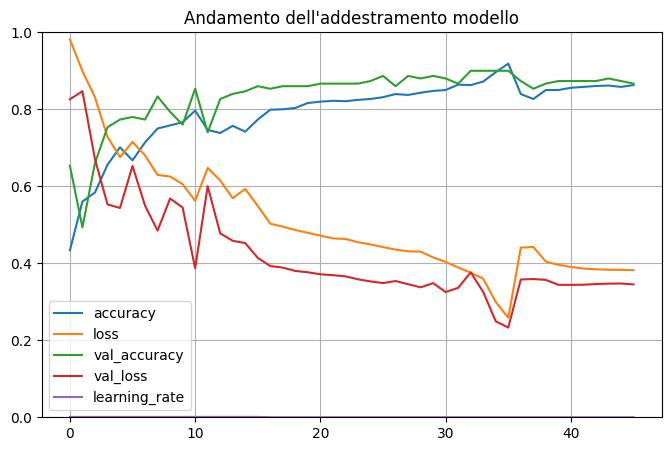

In [ ]:
from tensorflow.keras.models import Model


# Rimane invariato rispetto al blocco residuale della waveNet per la generazione
def residual_block(x, filters, kernel_size, dilation_rate):
    # Convoluzione causale dilatata
    res = layers.Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding="causal")(x)
    res = layers.ReLU()(res)

    # Convoluzione successiva
    res = layers.Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding="causal")(res)

    # Connessione residua
    res = layers.Add()([x, res])  # Sommatoria dell'input con l'output
    res = layers.ReLU()(res)  # Attivazione finale

    return res

def build_wavenet(num_blocks, filters, kernel_size, dilation_rates):
    inputs = layers.Input((MAX_DURATION*TARGET_SR,))
    reshape_input = layers.Reshape((MAX_DURATION * TARGET_SR, 1))(inputs)


    # Primo strato di convoluzione per mappare l'input
    x = layers.Conv1D(filters, kernel_size, padding="causal")(reshape_input)

    # Creazione di una serie di blocchi residuali
    for i in range(num_blocks):
        dilation_rate = dilation_rates[i % len(dilation_rates)]  # Cicla tra dilation rates
        x = residual_block(x, filters, kernel_size, dilation_rate)

    # Strato finale per la classificazione
    x = layers.GlobalAveragePooling1D()(x)  # Pooling globale per ridurre la dimensione temporale
    x = layers.Dense(64, activation="relu")(x)  # Un layer fully connected
    output = layers.Dense(3, activation="softmax")(x)  # Softmax per classificazione multi-classe

    # Generazione del modello
    model = Model(inputs, output)

    return model

# Configurazioni
input_shape = (None, 1)  # Input con una sequenza di campioni (audio a campione singolo)
num_classes = 10  # Numero di classi per la classificazione
num_blocks = 10  # Numero di blocchi residuali
filters = 64  # Numero di filtri per convoluzione
kernel_size = 2  # Dimensione del kernel
dilation_rates = [1, 2, 4, 8, 16]  # Dilation rates

wavenet = build_wavenet(num_blocks, filters, kernel_size, dilation_rates)

compile_and_fit(wavenet, train_ds, validation_ds, epochs=300, optimizer="adam", callbacks=[early_stopping, decay_learning_rate])

I risultati, come ci si poteva aspettare non sono dei migliori visto che la waveNet è una rete con molti parametri e profonda e questo la rende difficile da addestrare con un dataset con pochi meno di 1000 campioni come il nostro.

#### 4.5.2 Modello `slim_waveNet`

Dopo aver implementato il modello WaveNet modifiato per la classificazione audio, ho cercato di sviluppare una versione ottimizzata, denominata da me **`slim_waveNet`**, che mantenga l'intuizione di base della WaveNet, ovvero l'utilizzo di **strati convoluzionali con dilatazione crescente** e **padding causale**, ma con l'obiettivo di rendere il **training più veloce** e **ridurre il numero di parametri** utilizzati.

Il modello **`slim_waveNet`** si propone di **semplificare l'architettura** della WaveNet, mantenendo però l'intuizione di base delle convoluzioni causali con dilatazione crescente. In particolare, le modifiche introdotte includono:

1. **Eliminazione delle connessioni residue**: Una delle principali differenze rispetto alla WaveNet classica è l'eliminazione di connessioni residue tra i vari strati, riducendo la complessità computazionale e migliorando la velocità di addestramento.
   
2. **Riduzione dei parametri**: In `slim_waveNet`, sono stati ridotti il numero di filtri e le dimensioni dei kernel nei vari strati convoluzionali. Mantenendo la dilatazione crescente, ma con una struttura più snella, il modello riduce significativamente il numero di parametri senza compromettere la capacità di apprendimento delle caratteristiche temporali nei segnali audio.

3. **Ottimizzazione del training**: Grazie alla riduzione delle connessioni e dei parametri, `slim_waveNet` è progettato per addestrarsi più velocemente rispetto alla WaveNet classica, mantenendo prestazioni competitive nella generazione e classificazione di segnali audio.

In sintesi, mentre la **WaveNet classica** è molto potente per la generazione di audio grazie alla sua architettura profonda e alla dilatazione crescente, il **`slim_waveNet`** cerca di ottimizzare il processo di addestramento, riducendo i parametri e accelerando il training, senza sacrificare la capacità di catturare le dinamiche temporali cruciali per la generazione di audio.
Si cerca quindi di semplificare un modello nato per la generazione di audio ad una rete ottimizzata per svolgere un compito sicuramente più semplice che è quello della classificazione.


In [ ]:
# Modello che prende spunto dalla waveNet ma ha l'obiettivo di dimezzare il numero dei parametri
slim_waveNet = models.Sequential([
    layers.Input(shape=(MAX_DURATION*TARGET_SR,)),
    layers.Reshape((MAX_DURATION*TARGET_SR, 1)),
    # Primo layer di convoluzione causale con dilatazione 1
    layers.Conv1D(64, kernel_size=2, dilation_rate=1, padding='causal', activation='relu'),

    # Strati convoluzionali con dilatazione crescente intervallati da livelli di MaxPooling e Dropout per ridurre overfitting
    layers.Conv1D(64, kernel_size=2, dilation_rate=2, padding='causal', activation='relu'),
    layers.Conv1D(64, kernel_size=2, dilation_rate=4, padding='causal', activation='relu'),
    layers.MaxPooling1D(pool_size=16),
    layers.Dropout(0.2),

    layers.Conv1D(64, kernel_size=2, dilation_rate=8, padding='causal', activation='relu'),
    layers.Conv1D(64, kernel_size=2, dilation_rate=16, padding='causal', activation='relu'),
    layers.MaxPooling1D(pool_size=16),
    layers.Dropout(0.2),

    # Layer finali di convoluzioni senza dilation rate (per ottenere embedding)
    layers.Conv1D(128, kernel_size=1, activation='relu'),
    layers.Conv1D(128, kernel_size=1, activation='relu'),
    layers.MaxPooling1D(pool_size=16),
    layers.Dropout(0.2),

    # Strato di pooling per ridurre la dimensionalità
    layers.GlobalMaxPooling1D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    # Strato fully connected per la classificazione finale
    layers.Dense(3, activation='softmax')
])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape_5 (Reshape)                  │ (None, 48000, 1)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_65 (Conv1D)                   │ (None, 48000, 64)           │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_66 (Conv1D)                   │ (None, 48000, 64)           │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_67 (Conv1D)                   │ (None, 48000, 64)           │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 3000, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 3000, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_68 (Conv1D)                   │ (None, 3000, 64)            │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_69 (Conv1D)                   │ (None, 3000, 64)            │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 187, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 187, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_70 (Conv1D)                   │ (None, 187, 128)            │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_71 (Conv1D)                   │ (None, 187, 128)            │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 11, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 11, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 66,499 (259.76 KB)

 Trainable params: 66,499 (259.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 29s 670ms/step - accuracy: 0.3815 - loss: 1.0499 - val_accuracy: 0.6933 - val_loss: 0.8863 - learning_rate: 0.0010
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 342ms/step - accuracy: 0.6147 - loss: 0.8906 - val_accuracy: 0.7400 - val_loss: 0.7237 - learning_rate: 0.0010
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 345ms/step - accuracy: 0.6132 - loss: 0.8113 - val_accuracy: 0.7467 - val_loss: 0.6813 - learning_rate: 0.0010
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 346ms/step - accuracy: 0.6713 - loss: 0.7270 - val_accuracy: 0.8000 - val_loss: 0.5506 - learning_rate: 0.0010
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 342ms/step - accuracy: 0.7256 - loss: 0.6197 - val_accuracy: 0.8267 - val_loss: 0.5080 - learning_rate: 0.0010
Epoch 6/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step - accuracy: 0.7197 - loss: 0.6482 - val_accuracy: 0.8400 - val_loss: 0.5189 - learning_rate: 0.0010
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step - accuracy: 0.7502 - l

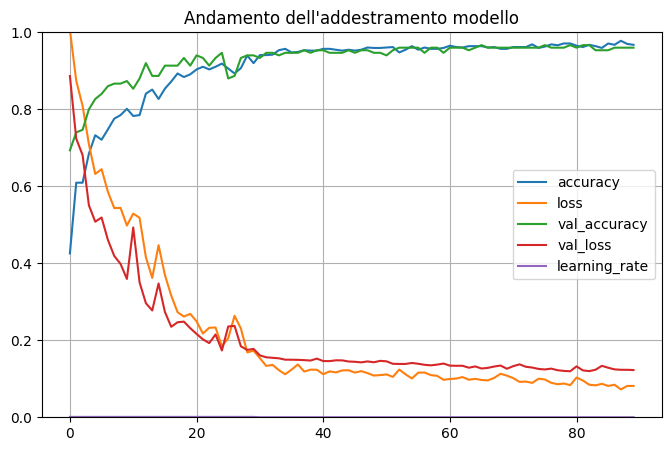

In [ ]:
compile_and_fit(slim_waveNet, train_ds, validation_ds, epochs=300, optimizer="adam", callbacks=[early_stopping, decay_learning_rate])

### 4.6. Modello sugli spettrogrammi


#### 4.6.1. Stabilire l'input

Il primo passo per creare un modello che riceve in input gli spettrogrammi è analizzare le diverse rappresentazioni degli spettrogrammi di un audio. Gli spettrogrammi sono rappresentazioni visive delle frequenze presenti in un segnale audio nel tempo, ottenute attraverso la trasformata di Fourier. Questi permettono di ottenere una visione più chiara delle caratteristiche del segnale audio, che possono essere utilizzate per il successivo processo di addestramento del modello.

Per questa analisi, sono state definite due funzioni differenti per stampare e visualizzare due tipologie di spettrogrammi:

1. **Spettrogramma STFT (Short-Time Fourier Transform)**:
   La funzione `plot_spectrogram_STFT` stampa lo spettrogramma in **scala lineare STFT**. La STFT è una trasformata che divide il segnale audio in segmenti temporali, analizzando la frequenza contenuta in ciascun segmento.  
   

2. **Spettrogramma di Mel**:
   La seconda funzione `plot_spectrogram_MEL` stampa lo **spettrogramma di Mel**, che è una rappresentazione del segnale audio che utilizza la **scala Mel** per la frequenza. La scala Mel è una scala di frequenza non lineare progettata per imitare la percezione umana del suono, in cui le frequenze più basse sono rappresentate in modo più dettagliato rispetto a quelle più alte. Questo tipo di spettrogramma è molto utilizzato per compiti legati al riconoscimento vocale e alla sintesi del parlato, poiché è più vicino alla percezione uditiva umana.

In [ ]:
# Funzione per disegnare lo spettrogramma
def plot_spectrogram_STFT(audio, sr, fig, ax, title="Spettrogramma STFT", y_scale = "linear"):
    D = librosa.stft(audio)
    D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img = librosa.display.specshow(D_db if y_scale == "log" else np.abs(D), sr=sr, x_axis="time", y_axis=y_scale, ax=ax)
    fig.colorbar(img, ax=ax, format='%+2.0f dB' if y_scale == "log" else '%+2.0f')
    ax.set_title(title)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Frequenza (Hz)")

def plot_spectrogram_MEL(audio, sr, fig, ax, title="Spettrogramma MEL"):
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
    img = librosa.display.specshow(mel_spectrogram_db, sr=sr, x_axis="time", y_axis="mel")
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_title(title)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Frequenza (Hz)")

Per eseguire queste due funzioni andiamo a campionare randomicamente un audio dal nostro training set

In [ ]:
for x_batch, y_batch in train_ds.take(1):  # Prende il primo batch
    random_index = np.random.randint(len(x_batch)) # indice randomico
    audio_example = x_batch[random_index].numpy().squeeze() # Prendi l'audio
    label_example = class_names[np.argmax(y_batch[random_index].numpy())]  # Prendi il target


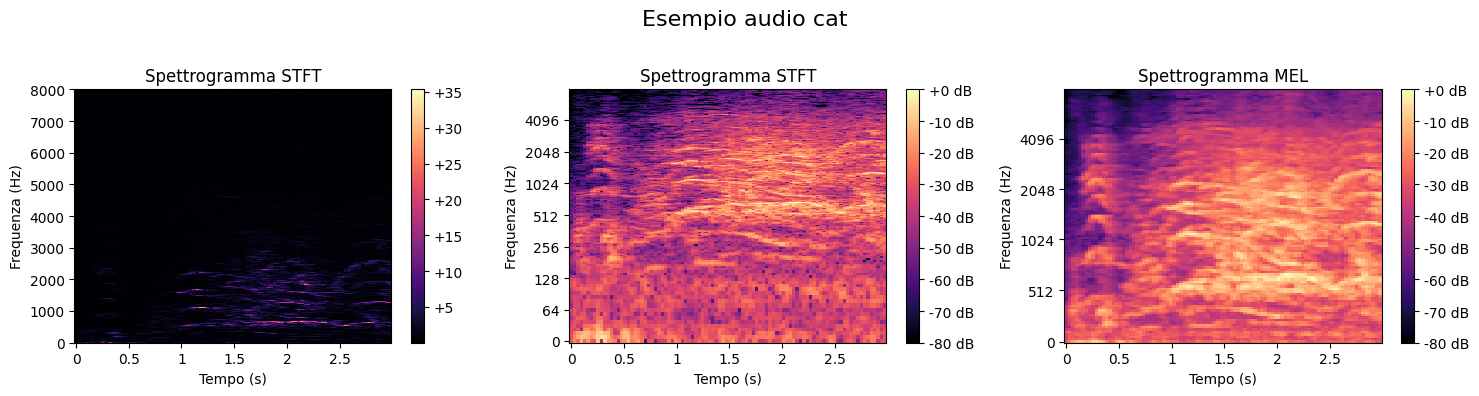

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Esempio audio {label_example}", fontsize=16)
plot_spectrogram_STFT(audio_example, TARGET_SR, fig, axes[0], y_scale="linear")
plot_spectrogram_STFT(audio_example, TARGET_SR, fig, axes[1], y_scale="log")
plot_spectrogram_MEL(audio_example, TARGET_SR, fig, axes[2])
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
D = librosa.stft(audio_example)
print(D.shape)
mel_spectrogram = librosa.feature.melspectrogram(y=audio_example, sr=TARGET_SR)
print(mel_spectrogram.shape)

(1025, 94)
(128, 94)


Come possiamo vedere, lo **spettrogramma STFT** in **scala lineare** perde molte caratteristiche. Considerando che gran parte dello spettrogramma risulta essere nero, si ha una dimensione grande dell'immagine con **dati "inutili"**.

In **scala logaritmica**, invece, otteniamo uno spettrogramma molto più ricco di informazioni, poiché le differenze di intensità vengono enfatizzate. L'analisi dimensionale, inoltre, ci permette di osservare come l'utilizzo dello **spettrogramma MEL** ci consenta di mantenere un alto grado di informazione, ma a una dimensione notevolmente ridotta, migliorando l'efficienza computazionale senza perdere dettagli importanti.


Inoltre, un altro lato positivo è che esiste un **layer in Keras** apposito per la generazione di uno spettrogramma a partire da una forma d'onda grezza. In questo modo, possiamo utilizzare gli stessi set di dati impiegati nei modelli precedenti anche per i modelli basati su spettrogrammi.

Il vantaggio aggiuntivo è che, durante l'inferenza, è possibile fornire direttamente l'**audio grezzo** al modello per effettuare la predizione, senza la necessità di pre-processare ulteriormente l'audio in uno spettrogramma, rendendo il processo più semplice e veloce.


In [ ]:
LayerMelSpectrogram = tf.keras.layers.MelSpectrogram(
    fft_length=2048,                # Lunghezza della FFT, permette una buona risoluzione in frequenza (2048 per frequenze più alte)
    sequence_stride=512,             # Passo tra i frame (stride). 512 offre un buon compromesso tra risoluzione temporale e frequenziale
    sequence_length=None,           # Lunghezza della sequenza in input (lasciato a None per adattarsi automaticamente alla lunghezza dell'input)
    window="hann",                  # Finestra di tipo Hann, spesso usata per ridurre l'effetto di leakage
    sampling_rate=16000,            # Frequenza di campionamento del segnale audio (16 kHz)
    num_mel_bins=128,               # Numero di bande Mel. 128 è una scelta comune per audio generico
    min_freq=20.0,                  # Frequenza minima. Per i versi di animali, 20 Hz è un buon valore
    max_freq=None,                  # Frequenza massima. Nessun limite specifico, usa la massima possibile data la FFT e la frequenza di campionamento
    power_to_db=True,               # Applicare la conversione in decibel (dB), utile per stabilizzare le variazioni di intensità
    top_db=80.0,                    # Ridurre il range dinamico, imposta il massimo valore di dB da normalizzare a 0
    mag_exp=2.0,                     # Elevato il quadrato della magnitudine per enfatizzare i picchi di intensità
    min_power=1e-10,                # Valore minimo di potenza per evitare log(0)
    ref_power=1.0                   # Normalizzazione della potenza rispetto a questo valore
)

#### 4.6.2. Modello **`simil_AlexNet`**
Dopo aver testato la **AlexNet** vista a lezione con risultati pessimi anche in questo caso, supponendo che il compito di classificazione rispetto al dataset **MNIST** fosse molto più semplice, ho provveduto a modificare la rete tramite tentativi logici con l'obiettivo di **semplificare la rete** e **diminuire il numero di parametri**, considerando la dimensione ridotta del dataset di training rispetto a MNIST.

La rete prodotta dopo svariati tentativi è stata chiamata **`simil_AlexNet`** e porta con sé le seguenti principali modifiche:

**Struttura dei Layer Convoluzionali**
- **`AlexNet`**: 5 strati convoluzionali con filtri crescenti (96, 256, 384, 384, 256) e kernel più grandi (11x11, 5x5, 3x3).
- **`simil`**: 3 strati convoluzionali con filtri più piccoli (32, 64, 128) e kernel più piccoli (3x3, 5x5).

**Strati Fully Connected (Dense)**
- **`AlexNet`**: 2 strati densi da 4096 neuroni ciascuno.
- **`simil`**: 2 strati densi da 64 e 32 neuroni, con dropout.

**Numero di Parametri**
- **`AlexNet`**: Maggiore numero di parametri a causa della profondità e dimensione dei layer convoluzionali e fully connected.
- **`simil`**: Numero inferiore di parametri, più efficiente dal punto di vista computazionale.

**Complesso vs Leggero**
- **`AlexNet`**: Modello più complesso, adatto a task complessi, maggiore capacità di apprendimento ma maggiore rischio di overfitting.
- **`simil`**: Modello più leggero, più veloce da addestrare, adatto a task più semplici.

**Tempo di Addestramento e Risorse**
- **`AlexNet`**: Richiede più risorse computazionali e tempo di addestramento.
- **`simil`**: Più rapido nell'addestramento e adatto a hardware meno potente.


In [ ]:
# Modello di partenza AlexNet rivisitato per eliminare molti parametri
simil_AlexNet = models.Sequential([
    layers.Input(shape=(MAX_DURATION*TARGET_SR,)),
    LayerMelSpectrogram,
    layers.Reshape((128, 94, 1)),

    # Primo blocco convoluzionale
    layers.Conv2D(32, kernel_size=(3, 3), strides=(2, 2), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    # Secondo blocco convoluzionale
    layers.Conv2D(64, kernel_size=(5, 5), padding="same", activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    # Terzo blocco convoluzionale
    layers.Conv2D(128, kernel_size=(3, 3), padding="same", activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    # Flatten per passare ai livelli completamente connessi (Dense)
    layers.Flatten(),

    # Primo Fully Connected Layer
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),  # Per ridurre overfitting

    # Secondo Fully Connected Layer
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),

    # Ultimo strato (Softmax per classificazione su N classi)
    layers.Dense(3, activation='softmax')
])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mel_spectrogram (MelSpectrogram)     │ (None, 128, 94)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 128, 94, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 63, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 63, 46, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 22, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 31, 22, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 31, 22, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 15, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 15, 10, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 15, 10, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3584)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         229,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 357,955 (1.37 MB)

 Trainable params: 357,507 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 84s 283ms/step - accuracy: 0.5021 - loss: 2.1220 - val_accuracy: 0.4533 - val_loss: 2.2081 - learning_rate: 0.0010
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6838 - loss: 0.8305 - val_accuracy: 0.4600 - val_loss: 2.0364 - learning_rate: 0.0010
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7431 - loss: 0.6331 - val_accuracy: 0.7333 - val_loss: 0.6779 - learning_rate: 0.0010
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8112 - loss: 0.4613 - val_accuracy: 0.6533 - val_loss: 0.7916 - learning_rate: 0.0010
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8321 - loss: 0.4682 - val_accuracy: 0.5867 - val_loss: 1.3703 - learning_rate: 0.0010
Epoch 6/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8604 - loss: 0.3904 - val_accuracy: 0.9000 - val_loss: 0.2519 - learning_rate: 0.0010
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8654 - loss: 0.3430 

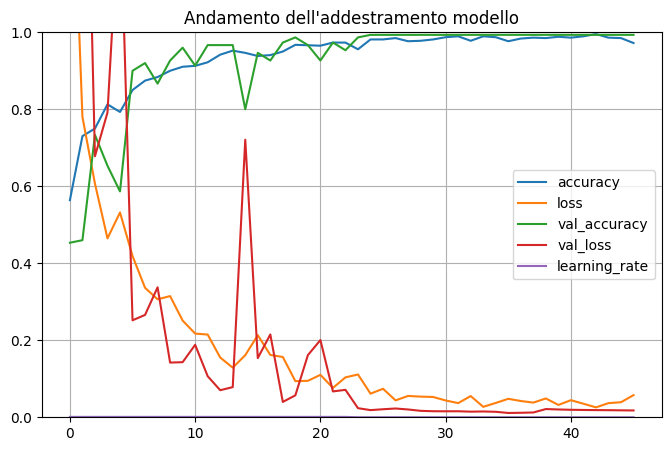

In [ ]:
compile_and_fit(simil_AlexNet, train_ds, validation_ds, epochs=300, optimizer="adam", callbacks=[early_stopping,decay_learning_rate])

#### 4.6.3. Modello **`slim_simil_AlexNet`**
Una volta ottenuti questi livelli di accuratezza, ho cercato di modificare il modello per avere un numero di parametri paragonabile a quello di **`slim_waveNet`**. Il risultato di queste modifiche è **`slim_simil_AlexNet`**, in cui sono state apportate due principali modifiche:

1. **Eliminazione del livello denso** da 128 neuroni.
2. **Riduzione del `kernel_size`** del secondo blocco convoluzionale da (5,5) a (3,3).

Queste due modifiche hanno reso il modello paragonabile, in termini di numero di parametri, a quello della **`slim_waveNet`** e con i seguenti risultati:

In [ ]:
# Modello di partenza AlexNet rivisitato per eliminare molti parametri
slim_simil_AlexNet = models.Sequential([
    layers.Input(shape=(MAX_DURATION*TARGET_SR,)),
    LayerMelSpectrogram,
    layers.Reshape((128, 94, 1)),

    # Primo blocco convoluzionale
    layers.Conv2D(32, kernel_size=(3, 3), strides=(2, 2), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Secondo blocco convoluzionale
    layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Terzo blocco convoluzionale
    layers.Conv2D(128, kernel_size=(3, 3), padding="same", activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Cambiato questo
    layers.GlobalMaxPool2D(),

    # Secondo Fully Connected Layer
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),

    # Ultimo strato
    layers.Dense(3, activation='softmax')
])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mel_spectrogram (MelSpectrogram)     │ (None, 128, 94)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 128, 94, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 63, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 63, 46, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 31, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 31, 23, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 31, 23, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 15, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 15, 11, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 15, 11, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 7, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling2d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling2D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 97,795 (382.01 KB)

 Trainable params: 97,347 (380.26 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 220ms/step - accuracy: 0.6485 - loss: 1.5502 - val_accuracy: 0.3400 - val_loss: 4.9542 - learning_rate: 0.0010
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8252 - loss: 0.3856 - val_accuracy: 0.4200 - val_loss: 1.9386 - learning_rate: 0.0010
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8689 - loss: 0.3061 - val_accuracy: 0.5600 - val_loss: 1.2457 - learning_rate: 0.0010
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9143 - loss: 0.2232 - val_accuracy: 0.7400 - val_loss: 0.6553 - learning_rate: 0.0010
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9075 - loss: 0.2353 - val_accuracy: 0.7800 - val_loss: 0.4443 - learning_rate: 0.0010
Epoch 6/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9412 - loss: 0.1496 - val_accuracy: 0.8733 - val_loss: 0.2504 - learning_rate: 0.0010
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9355 - loss: 0.1654 

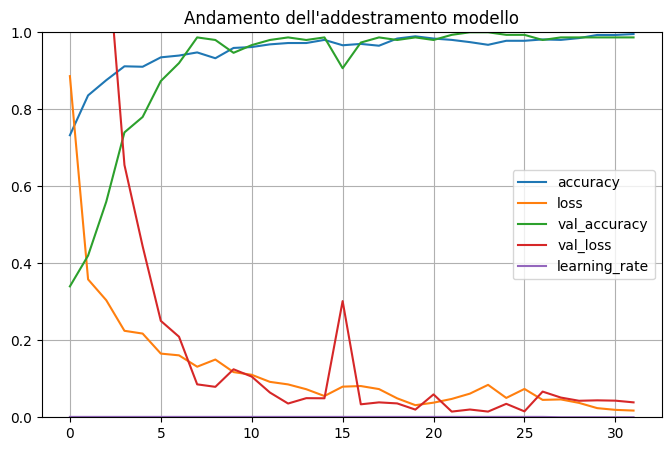

In [ ]:
compile_and_fit(slim_simil_AlexNet, train_ds, validation_ds, epochs=300, optimizer="adam", callbacks=[early_stopping,decay_learning_rate])

## 5. Valutazione dei modelli scelti
Dopo aver analizzato i risultati di **accuracy** e **loss** sul set di validazione, possiamo dedurre che, dal punto di vista dell'accuratezza, i modelli migliori in entrambe le categorie sono:

- **`slim_waveNet`** per le forme d'onda grezze.
- **`simil_AlexNet`** per gli spettrogrammi.

Naturalmente, se consideriamo anche il **numero di parametri** del modello e, quindi, la possibilità di eseguire i modelli anche su sistemi embedded, entra in considerazione anche il modello **`slim_simil_AlexNet`** per gli spettrogrammi, che risparmia 2/3 dei parametri rispetto a **`simil_AlexNet`**.

Di conseguenza, analizziamo le prestazioni sul **test set** di **`slim_waveNet`** per le forme d'onda e per gli **spettrogrammi**, considerando entrambi, viste le considerazioni appena effettuate.

### 5.1. Valutazione **`slim_waveNet`**

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - accuracy: 0.8853 - loss: 0.5396
Test Loss: 0.5058715343475342
Test Accuracy: 0.8877550959587097
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step


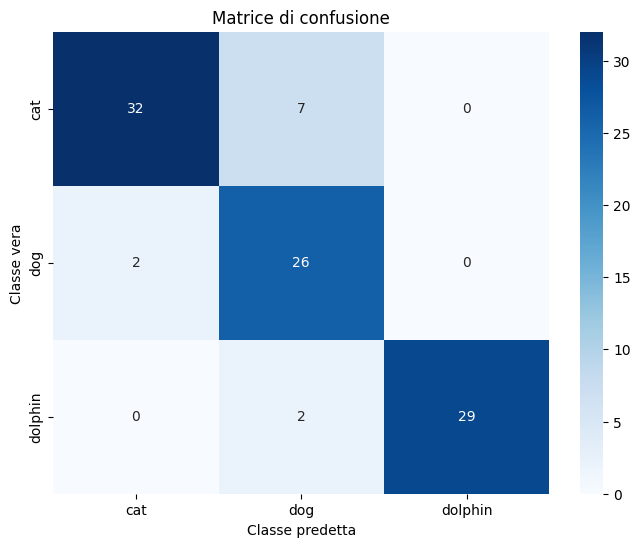

Metriche per ciascuna classe:
cat - Precision: 0.9412, Recall: 0.8205, F1 Score: 0.8767
dog - Precision: 0.7429, Recall: 0.9286, F1 Score: 0.8254
dolphin - Precision: 1.0000, Recall: 0.9355, F1 Score: 0.9667


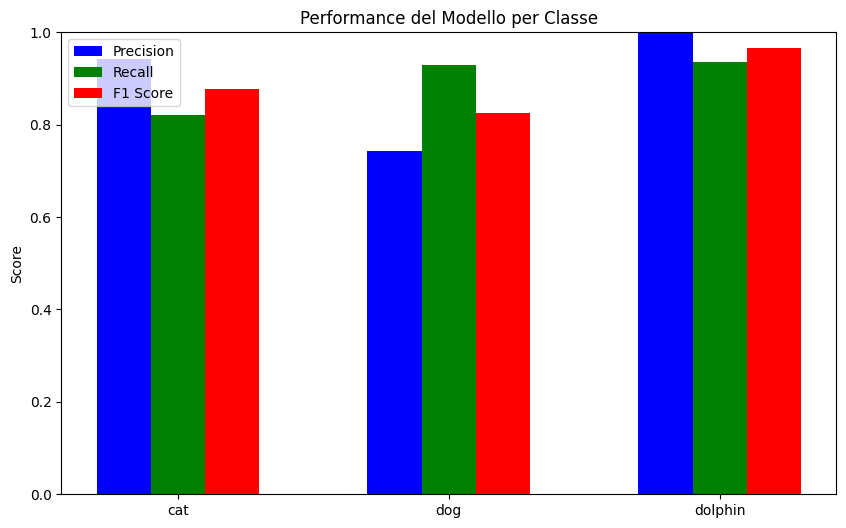

In [ ]:
evaluate_model(slim_waveNet, test_ds)

### 5.2. Valutazione **`simil_AlexNet`**

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9938 - loss: 0.0116 
Test Loss: 0.018463291227817535
Test Accuracy: 0.9897959232330322
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


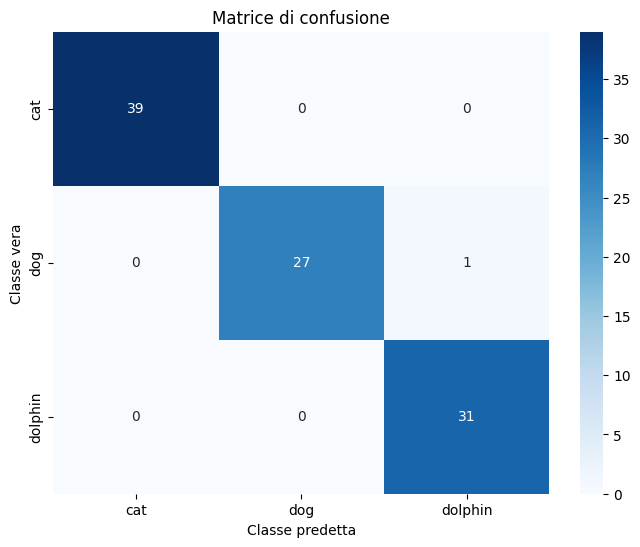

Metriche per ciascuna classe:
cat - Precision: 1.0000, Recall: 1.0000, F1 Score: 1.0000
dog - Precision: 1.0000, Recall: 0.9643, F1 Score: 0.9818
dolphin - Precision: 0.9688, Recall: 1.0000, F1 Score: 0.9841


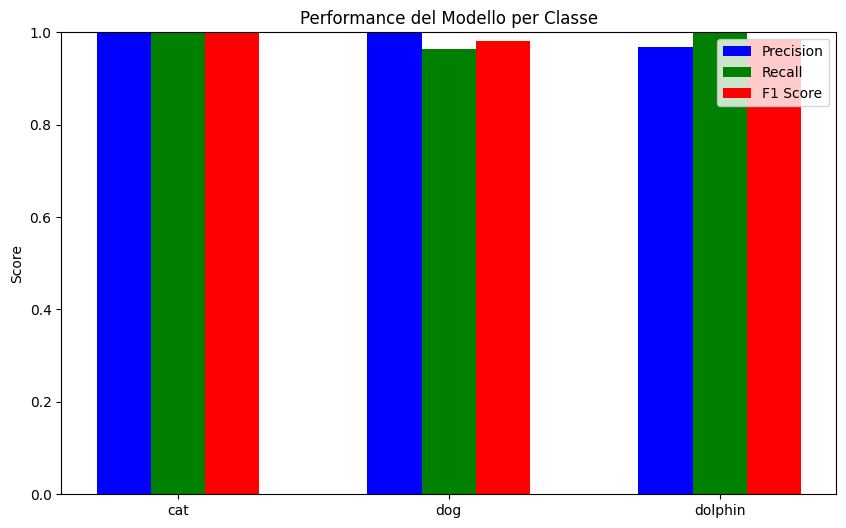

In [ ]:
evaluate_model(simil_AlexNet, test_ds)

### 5.3. Valutazione **`slim_simil_AlexNet`**

4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 120ms/step - accuracy: 0.9660 - loss: 0.0814
Test Loss: 0.10509363561868668
Test Accuracy: 0.9591836929321289
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step


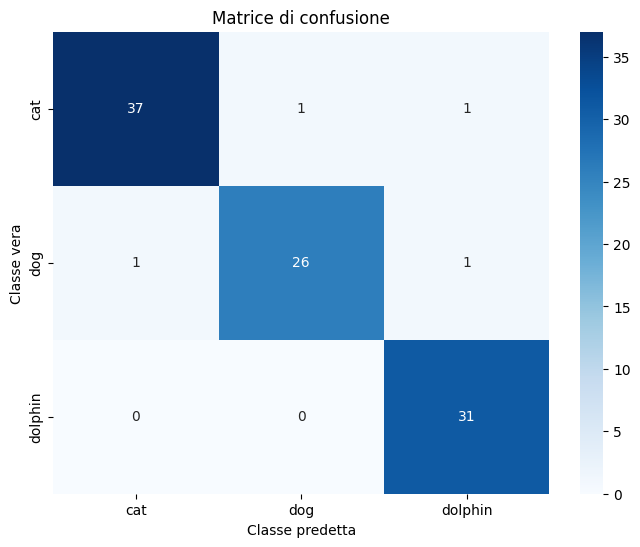

Metriche per ciascuna classe:
cat - Precision: 0.9737, Recall: 0.9487, F1 Score: 0.9610
dog - Precision: 0.9630, Recall: 0.9286, F1 Score: 0.9455
dolphin - Precision: 0.9394, Recall: 1.0000, F1 Score: 0.9688


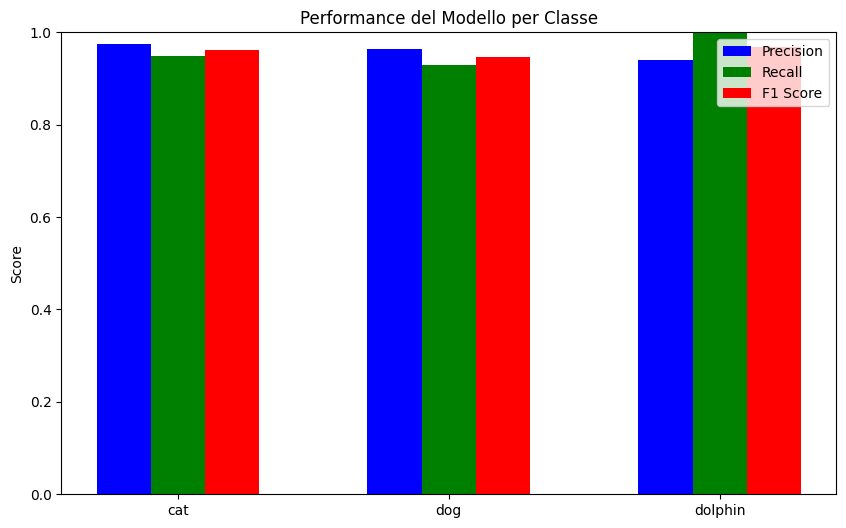

In [ ]:
evaluate_model(slim_simil_AlexNet, test_ds)

## 6. Segmentazione e Permutazione (Possibile data augmentation non applicata)
Come già citato in precedenza, nel **3° capitolo della [Analisi operativa del dataset]**, il primo approccio alla **data augmentation** per il dataset *dog_cat_dolphin* che ho provato è quello che tutt'ora mi risulta molto interessante, ovvero la **segmentazione degli audio e la permutazione dei versi**.

L'idea alla base è quella di prendere ogni campione del dataset, in cui sono contenuti diversi versi di quell'animale, e dividere l'audio in segmenti che contengono un singolo verso dell'animale. Successivamente, questi segmenti vengono rimescolati, effettuando una permutazione, per generare degli audio sintetici che imiterebbero il continuo della registrazione segmentata.

Questa procedura di **data augmentation** è fattibile in questo caso perché, al contrario delle parole di un umano, i versi non hanno un significato posizionale. Quindi, attualmente, l'unico settore in cui è possibile applicare un dataset augmentation di questa tipologia è proprio sugli audio degli animali.

Il vantaggio di questa procedura è che, essendo n il numero di segmenti, il numero di permutazioni massime è pari a **n!**, permettendo di aumentare **fattorialmente** il nostro dataset, almeno in teoria (possibile overfitting).

Il motivo per cui non è stato più applicato questo metodo è che l'obbligo di **troncare gli audio** a una durata irrisoria (3 secondi) a causa delle scarse risorse computazionali rende il processo **completamente inutile**.

Successivamente si descrive comunque il procedimento:

### 6.1. Librerie utilizzate

### 6.2. Rimozione del rumore
Il primo passo per individuare le diverse vocalizzazioni degli animali contenute negli audio è indispensabile procedere con una rimozione del rumore.
Per fare questo dobbiamo prima di tutto **attenuare il più possibile il rumore** all'interno delle nostre tracce, in modo da poter dividere i vari versi tramite i momenti di **silenzio** all'interno della traccia.

#### 6.2.1 Filtro Passa-Banda
Per la **riduzione del rumore**, possiamo attuare diverse tecniche. La scelta che pare più conveniente è quella di, innanzitutto, **eliminare le frequenze in cui non ci sono i versi degli animali** in questione. Anche se questo risulta essere un filtro molto grezzo, è molto utile nel caso in cui il rumore al di fuori della frequenza del verso degli animali sia più intenso del volume dell'animale stesso. In questa maniera, possiamo rendere più efficace l'applicazione del filtro successivo. Questo è stato possibile grazie all'analisi teorica effettuata nel secondo capitolo.

Creiamo una funzione per applicare filtro passa-banda/passa-basso/passa-alto ai nostri audio.

In [ ]:
from scipy.signal import butter, filtfilt

In [ ]:
def filtra_audio(y, sr, filter_type, low_cut=None, high_cut=None, order=4):
    # Verifica che i parametri siano validi
    if filter_type not in ['passa-banda', 'passa-alto', 'passa-basso']:
        raise ValueError("Tipo di filtro non supportato. Usa 'passa-banda', 'passa-alto' o 'passa-basso'.")

    if low_cut is not None and low_cut < 0:
        raise ValueError("La frequenza di taglio inferiore (low_cut) non può essere negativa.")
    if high_cut is not None and high_cut > sr / 2:
        raise ValueError("La frequenza di taglio superiore (high_cut) non può superare la frequenza di Nyquist (sr / 2).")
    if filter_type == 'passa-banda' and (low_cut is None or high_cut is None or low_cut >= high_cut):
        raise ValueError("Per un filtro passa-banda, low_cut deve essere inferiore a high_cut.")

    # Normalizza le frequenze di taglio
    nyquist = 0.5 * sr
    if low_cut is not None:
        low_cut_normalized = low_cut / nyquist
    if high_cut is not None:
        high_cut_normalized = high_cut / nyquist

    # Progetta il filtro
    if filter_type == 'passa-banda':
        b, a = butter(order, [low_cut_normalized, high_cut_normalized], btype='band')
    elif filter_type == 'passa-alto':
        b, a = butter(order, low_cut_normalized, btype='high')
    elif filter_type == 'passa-basso':
        b, a = butter(order, high_cut_normalized, btype='low')

    # Applica il filtro
    y_filtrato = filtfilt(b, a, y)
    return y_filtrato

applichiamo il filtro passa-banda su tutti gli audio del training set basandoci sul range di frequenze descritte dalla teoria e sulle caratteristiche degli audio specifiche del nostro dataset.

In [ ]:
# Applichiamo dei filtri passa-banda per ridurre in modo grossolano il rumore nelle tracce audio
filtered_audio = defaultdict(list)
filtered_audio['cat'] = [None] * len(train_dict['cat'])
filtered_audio['dog'] = [None] * len(train_dict['dog'])
filtered_audio['dolphin'] = [None] * len(train_dict['dolphin'])

for idx, (audio, sr) in enumerate(train_dict['cat']):
    filtered_audio['cat'][idx] = (filtra_audio(audio, sr, filter_type='passa-banda', low_cut=500, high_cut=7000), sr)
for idx, (audio, sr) in enumerate(train_dict['dog']):
    filtered_audio['dog'][idx] = (filtra_audio(audio, sr, filter_type='passa-banda', low_cut=100, high_cut=3000), sr)
for idx, (audio, sr) in enumerate(train_dict['dolphin']):
    filtered_audio['dolphin'][idx] = (filtra_audio(audio, sr, filter_type='passa-banda', low_cut=2000, high_cut=60000), sr)

Risultati:

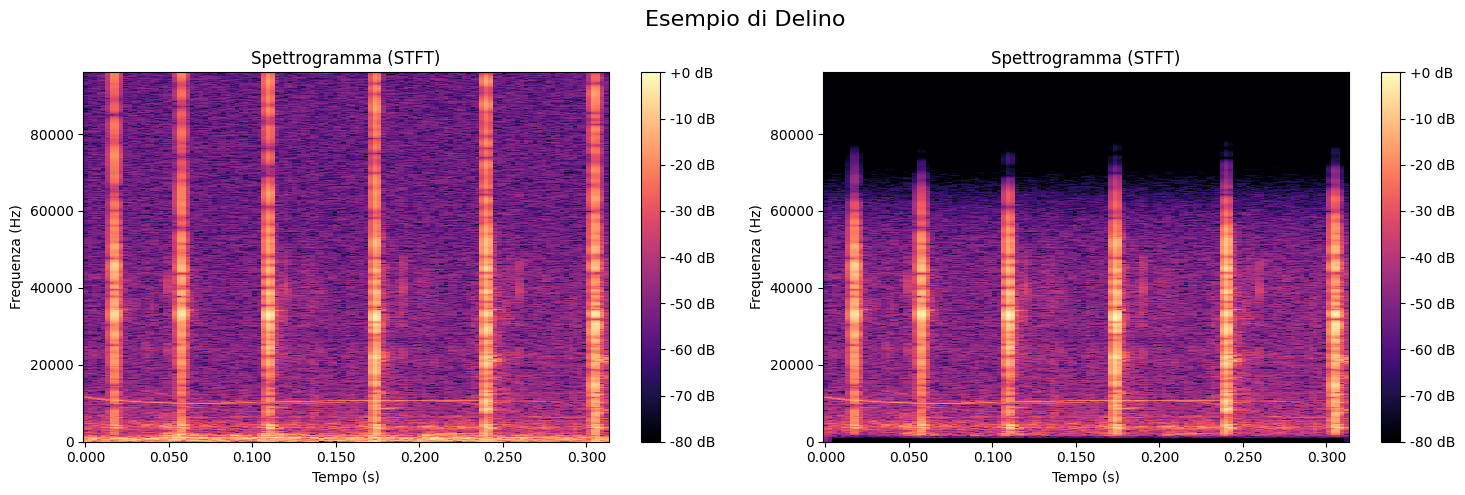

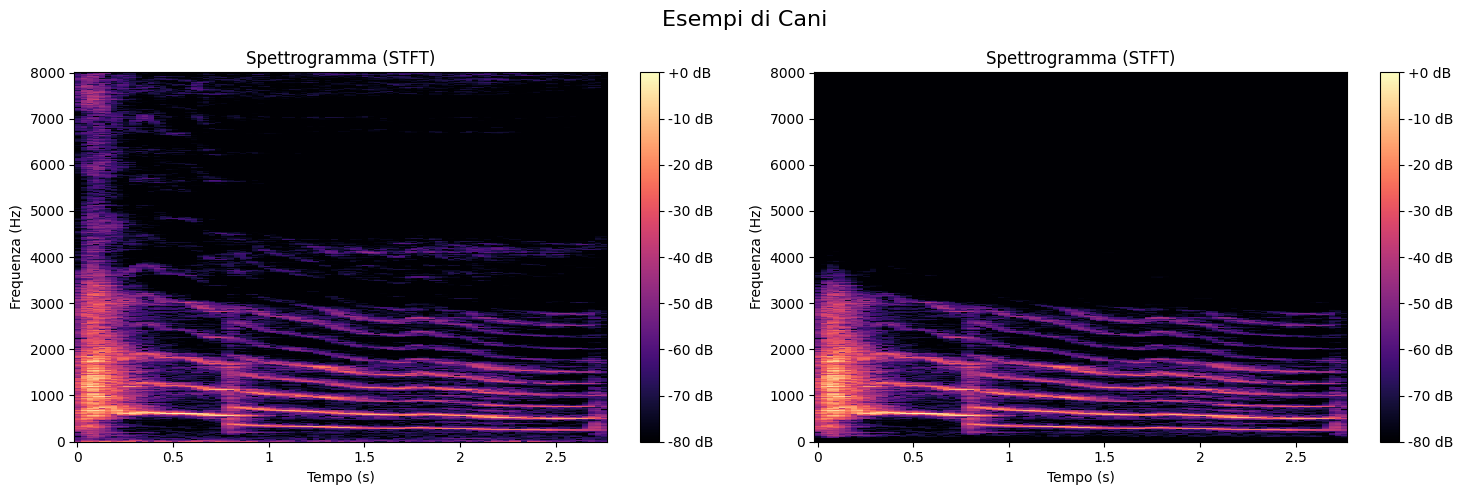

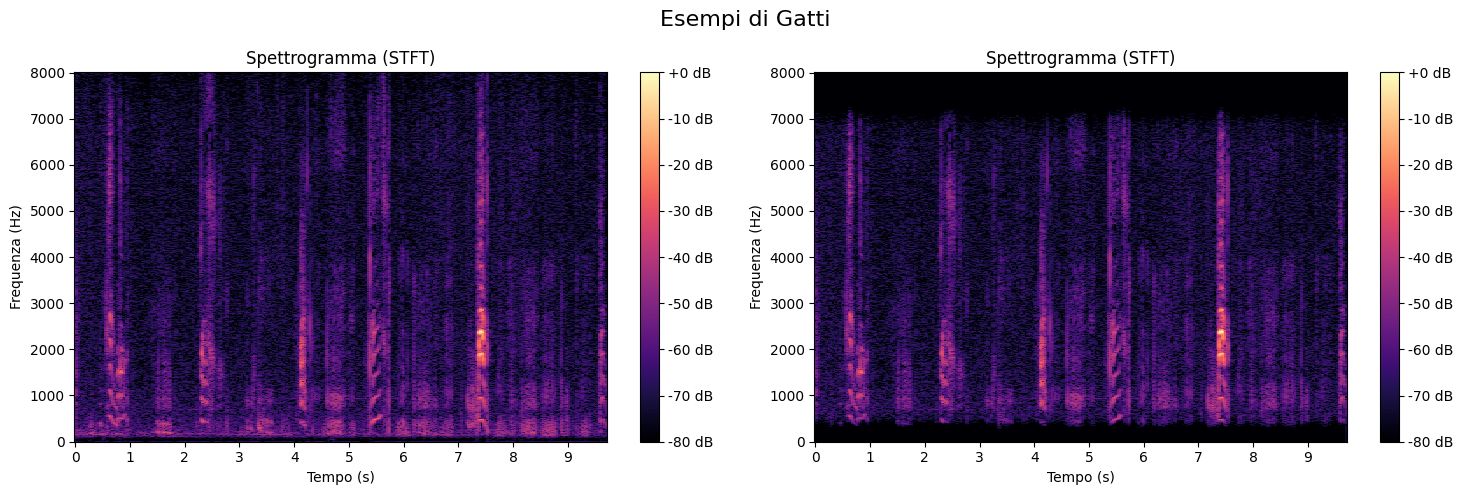

In [ ]:
# Stampa esempi delfini
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Esempio di Delino', fontsize=16)
# inseriamo lo spettrogramma STFT
plot_spectrogram_STFT(train_dict['dolphin'][0][0], train_dict['dolphin'][0][1], fig, axes[0], y_scale='linear')
plot_spectrogram_STFT(filtered_audio['dolphin'][0][0], filtered_audio['dolphin'][0][1], fig, axes[1], y_scale='linear')

plt.tight_layout()
plt.show()

# Stampa esempi Cani
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Esempi di Cani', fontsize=16)
# inseriamo lo spettrogramma STFT
plot_spectrogram_STFT(train_dict['dog'][0][0], train_dict['dog'][0][1], fig, axes[0], y_scale='linear')
plot_spectrogram_STFT(filtered_audio['dog'][0][0], filtered_audio['dog'][0][1], fig, axes[1], y_scale='linear')

plt.tight_layout()
plt.show()

# Stampa esempi Gatti
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Esempi di Gatti', fontsize=16)
# inseriamo lo spettrogramma STFT
plot_spectrogram_STFT(train_dict['cat'][0][0], train_dict['cat'][0][1], fig, axes[0], y_scale='linear')
plot_spectrogram_STFT(filtered_audio['cat'][0][0], filtered_audio['cat'][0][1], fig, axes[1], y_scale='linear')

plt.tight_layout()
plt.show()

#### 6.2.2. Noise reduction tramite `NoiseReduce`
Adesso passiamo ad un'altra tecnica di **noise reduction** che punta a cercare di rimuovere il rumore alle stesse frequenze delle tracce, come ad esempio il **riverbero** o altri tipi di rumore. A questo scopo, utilizziamo una libreria che implementa il meccanismo di **spectral gating**, chiamata **noisereduce**.

La libreria **noisereduce** utilizza un algoritmo di **spectral gating** per ridurre il rumore in una registrazione audio. Questo metodo lavora separando il segnale di rumore dalle informazioni utili dell'audio, agendo sulle frequenze in cui il rumore è più prominente e riducendolo senza compromettere troppo la qualità del segnale originale. La tecnica si basa su un'analisi della potenza del rumore in frequenze specifiche e agisce solo nelle aree dove il rumore è presente, preservando il contenuto del segnale audio.


In [ ]:
!pip install noisereduce
import noisereduce as nr

In [ ]:
# Andiamo ad applicare il filtro spectral gate usando noisereduce
for label, samples in filtered_audio.items():
    for idx, (audio, sr) in enumerate(samples):
        reduced_noise = nr.reduce_noise(
            y=audio,
            sr=sr,
            prop_decrease=0.9,          # riduzione più morbida (default è 1.0)
            time_mask_smooth_ms=32,     # smoothing nel tempo (default 63)
            n_fft=2048,                 # numero di punti FFT
            win_length=2048,            # lunghezza finestra in campioni
            hop_length=512,             # step tra una finestra e l’altra
            stationary=True
        )
        filtered_audio[label][idx] = (reduced_noise, sr)

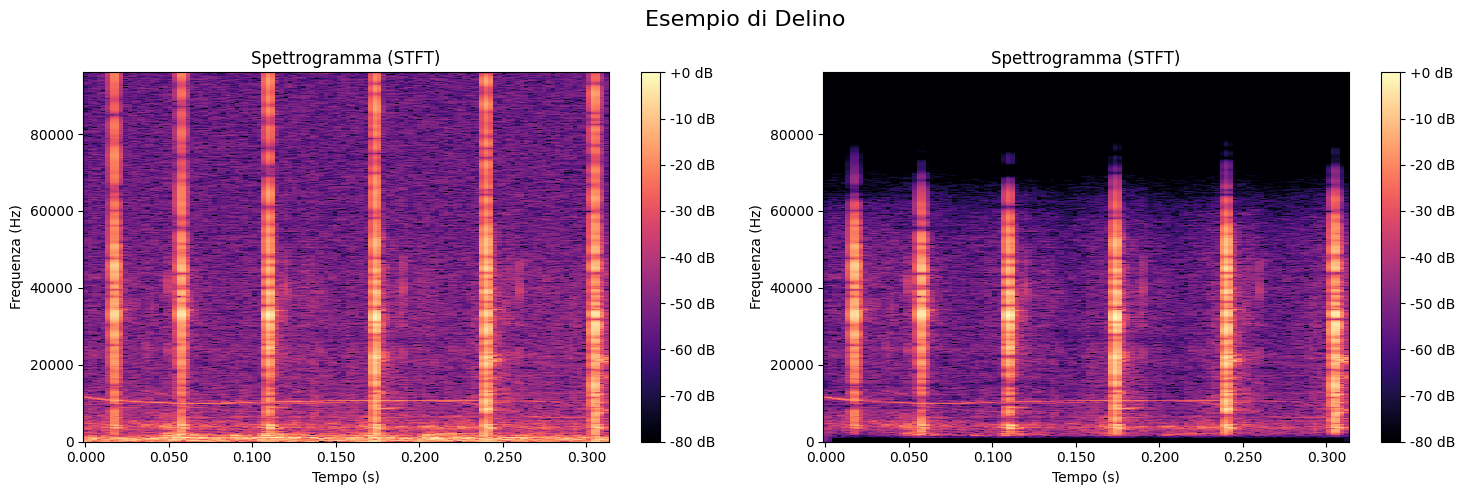

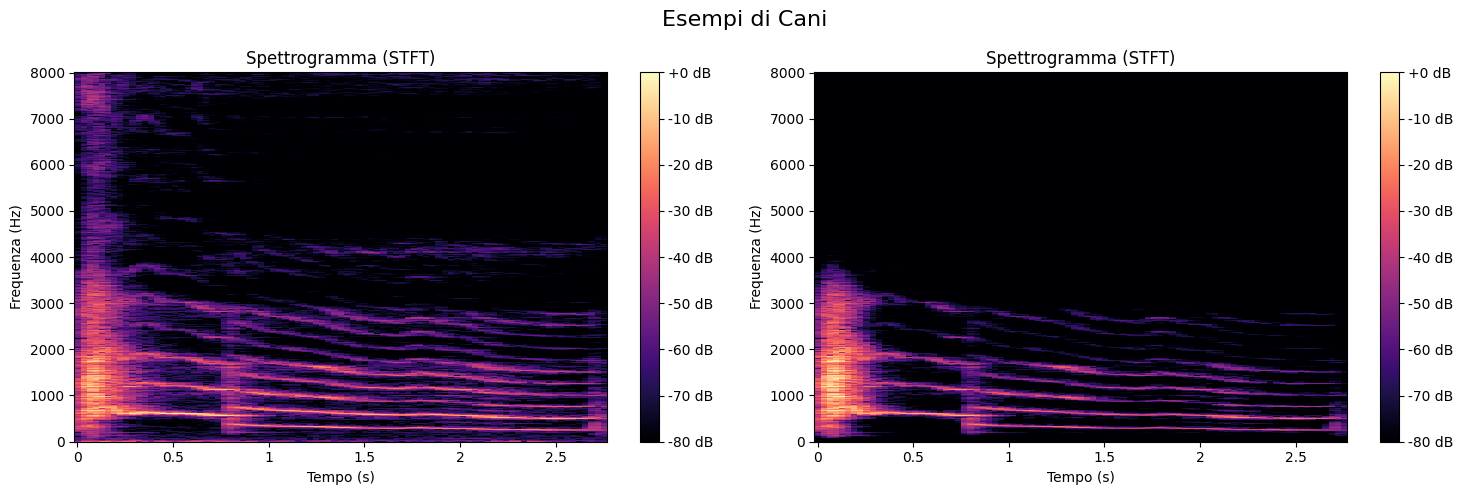

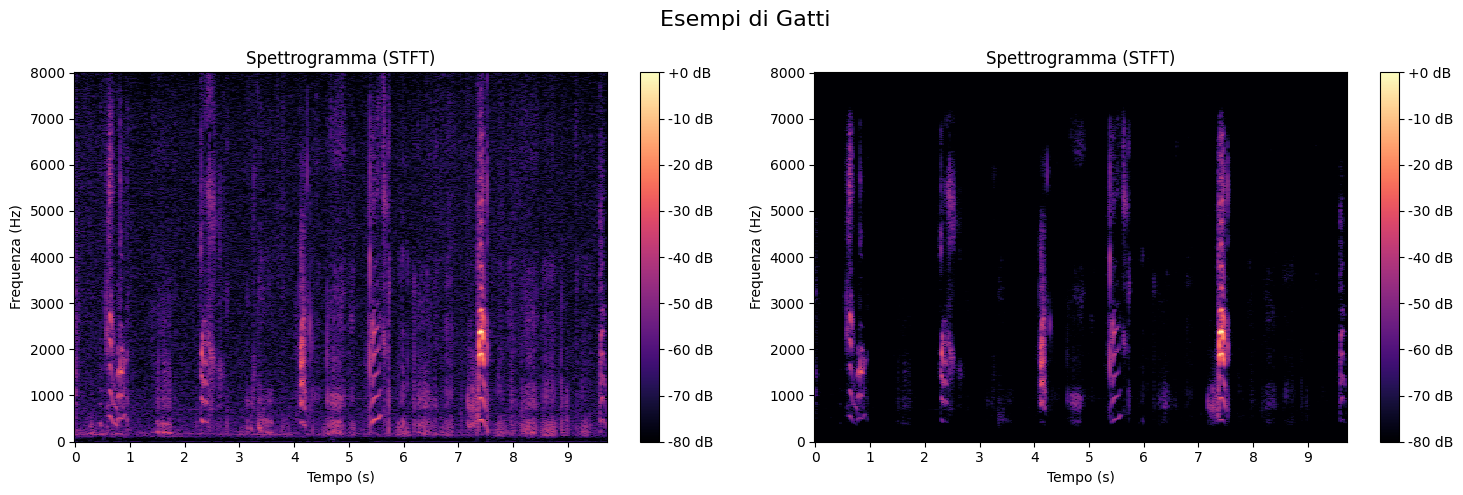

In [ ]:
# Stampa esempi delfini
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Esempio di Delino', fontsize=16)
# inseriamo lo spettrogramma STFT
plot_spectrogram_STFT(original_train['dolphin'][0][0], original_train['dolphin'][0][1], fig, axes[0], y_scale='linear')
plot_spectrogram_STFT(filtered_audio['dolphin'][0][0], filtered_audio['dolphin'][0][1], fig, axes[1], y_scale='linear')

plt.tight_layout()
plt.show()

# Stampa esempi Cani
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Esempi di Cani', fontsize=16)
# inseriamo lo spettrogramma STFT
plot_spectrogram_STFT(original_train['dog'][0][0], original_train['dog'][0][1], fig, axes[0], y_scale='linear')
plot_spectrogram_STFT(filtered_audio['dog'][0][0], filtered_audio['dog'][0][1], fig, axes[1], y_scale='linear')

plt.tight_layout()
plt.show()

# Stampa esempi Gatti
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Esempi di Gatti', fontsize=16)
# inseriamo lo spettrogramma STFT
plot_spectrogram_STFT(original_train['cat'][0][0], original_train['cat'][0][1], fig, axes[0], y_scale='linear')
plot_spectrogram_STFT(filtered_audio['cat'][0][0], filtered_audio['cat'][0][1], fig, axes[1], y_scale='linear')

plt.tight_layout()
plt.show()

### 6.3. Campionamento del silenzio
Una parte fondamentale delle **vocalizzazioni** è in realtà il **silenzio**, ovvero la cadenza tra una vocalizzazione e l'altra. Questo aspetto è cruciale per la naturalezza del suono e la sua interpretazione.  

Per imitare questo silenzio, campioniamo tutti i **silenzi tra le vocalizzazioni** all'interno del dataset e generiamo una **distribuzione normale** sulla quale possiamo effettuare campionamenti. Questo processo ci permette di **aumentare la variabilità** e di ottenere un dataset più realistico, migliorando così la capacità del modello di generalizzare a nuovi dati.

In [ ]:
TOP_DB = 55
#Data augmentation (Dividiamo in segmenti gli audio nei momenti di silenzio)
silent_samples = defaultdict(list)

# Estrazione dei campioni di silenzio per ogni audio di ogni animale
for label, samples in filtered_audio.items():
  for audio, sr in samples:
    intervals = librosa.effects.split(audio, top_db=TOP_DB)
    if len(intervals) >= 2:
      silence_intervals = [(intervals[i-1][1], intervals[i][0]) for i in range(1, len(intervals))]
      silent_samples[label].extend([(end - start) / sr for start, end in silence_intervals if end > start])

print(silent_samples)

defaultdict(<class 'list'>, {'cat': [0.416, 0.544, 0.512, 0.576, 0.576, 0.16, 0.352, 0.384, 0.608, 0.544, 0.096, 0.864, 0.128, 0.064, 0.736, 0.128, 0.384, 0.128, 0.032, 0.032, 0.064, 0.032, 0.544, 1.184, 0.416, 0.992, 0.64, 0.096, 1.088, 0.96, 0.736, 0.16, 0.192, 0.416, 0.032, 0.96, 0.128, 0.224, 0.224, 0.032, 0.032, 0.064, 0.096, 0.032, 0.448, 0.096, 0.096, 0.288, 0.224, 0.192, 0.128, 0.128, 0.064, 0.608, 0.928, 3.68, 0.896, 0.16, 0.096, 0.32, 0.384, 0.864, 0.032, 0.032, 0.032, 0.992, 0.672, 0.096, 0.096, 0.064, 0.192, 0.096, 0.064, 0.256, 0.096, 0.128, 0.448, 1.216, 0.032, 0.032, 0.032, 0.096, 0.224, 0.064, 0.608, 0.288, 0.704, 0.032, 0.256, 1.344, 0.16, 0.672, 0.192, 0.096, 0.032, 0.128, 0.512, 0.704, 0.704, 0.608, 0.864, 0.096, 0.192, 0.064, 0.064, 0.16, 0.032, 0.256, 0.192, 0.672, 0.224, 0.16, 0.032, 0.384, 0.16, 0.064, 0.32, 1.312, 0.96, 0.064, 0.064, 0.032, 0.16, 0.256, 1.184, 0.448, 0.096, 0.128, 0.192, 0.192, 0.064, 0.096, 0.032, 0.032, 0.032, 0.864, 0.864, 0.864, 0.864, 0.288

In [ ]:
import scipy.stats as stats
# Calcoliamo le distribuzioni normali per campionare casualmente un valore nei silenzi
silent_distr = {}
for label, values in silent_samples.items():
  if values: # Se ci sono dei dati
    mean = np.mean(values)
    std = np.std(values, ddof=1) # Corretta per piccoli valori
    # Limiti per la distribuzione troncata (non vogliamo che possano essere estratti valori negativi)
    a, b = (0 - mean) / std, np.inf  # Minimo a 0, massimo infinito
    silent_distr[label] = stats.truncnorm(a, b, loc=mean, scale=std)
  else:
    silent_distr[label] = None # Nessuna distribuzione nel caso di dati di silenzio mancanti

### 6.4. Creazione dei dati sintetici
Come ultima fase vi è la permutazione dei dati, si sceglie di permutare solo fra segmenti dello stesso audio in maniera tale da non avere campioni irrealistici (animali diversi possono avere vocalizzazioni a frequenze differenti)

In [ ]:
import math
import itertools

In [ ]:
MAX_PERMUTATIONS = {
    "dog": 6,
    "cat": 2,
    "dolphin": 12
}

augmented_audio = defaultdict(list) # dizionario dei dati aumentati

for label, samples in filtered_audio.items():
  for audio, sr in samples:
    intervals = librosa.effects.split(audio, top_db=TOP_DB)
    if len(intervals) != 1:
      #for interval in intervals:
        #augmented_audio[label].append((audio[interval[0]:interval[1]], sr)) # inseriamo anche i singoli segmenti come campioni nel dataset aumentato
      max_permutations = min(MAX_PERMUTATIONS[label], math.factorial(len(intervals)))
      permutations = list(itertools.islice(itertools.permutations(intervals), max_permutations))
      for perm in permutations:
        new_audio = []
        for i, interval in enumerate(perm):
          new_audio.append(audio[interval[0]:interval[1]])
          if i < len(perm) - 1:
            silence_duration = silent_distr[label].rvs()
            silence_sample = int(silence_duration * sr)
            new_audio.append(np.zeros(silence_sample))
        # Concatenazione dei segmenti e del silenzio in un unico array numpy
        concatenated_audio = np.concatenate(new_audio)
        augmented_audio[label].append((concatenated_audio, sr))

In [ ]:
# Esempio di dimostrazione
print("Audio originale")
play_audio(filtered_audio['cat'][1][0], filtered_audio['cat'][1][1])
print("Audio sintetizzato")
play_audio(augmented_audio['cat'][4][0], augmented_audio['cat'][4][1])
play_audio(augmented_audio['cat'][3][0], augmented_audio['cat'][3][1])





Audio originale


Audio sintetizzato


In [ ]:
print(f"Numero di dati sintetizzati per i gatti: {len(augmented_audio['cat'])}")
print(f"Numero di dati sintetizzati per i cani: {len(augmented_audio['dog'])}")
print(f"Numero di dati sintetizzati per i delfini: {len(augmented_audio['dolphin'])}")

Numero di dati sintetizzati per i gatti: 132
Numero di dati sintetizzati per i cani: 146
Numero di dati sintetizzati per i delfini: 38
